Upload one video. The code will first classify the head motion type, then run the matching rPPG pipeline.


Saving reza_period_01_rppg_input_20260603_202324.avi to reza_period_01_rppg_input_20260603_202324 (2).avi
Uploaded video: reza_period_01_rppg_input_20260603_202324 (2).avi

Running head motion classifier...

Head tracking preview frames:
Green box = detected face
Red dot = tracked head center


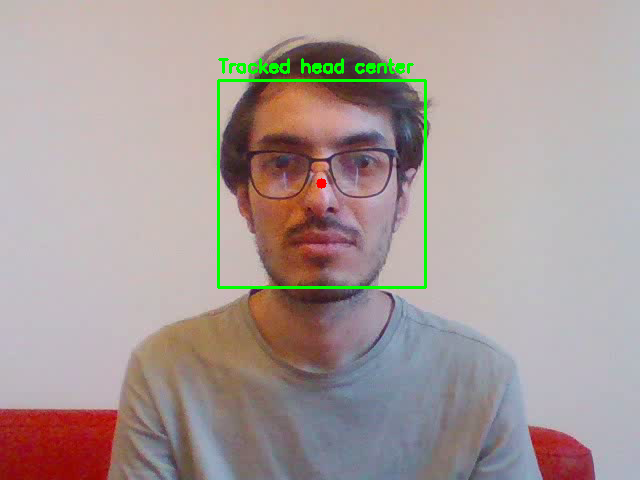

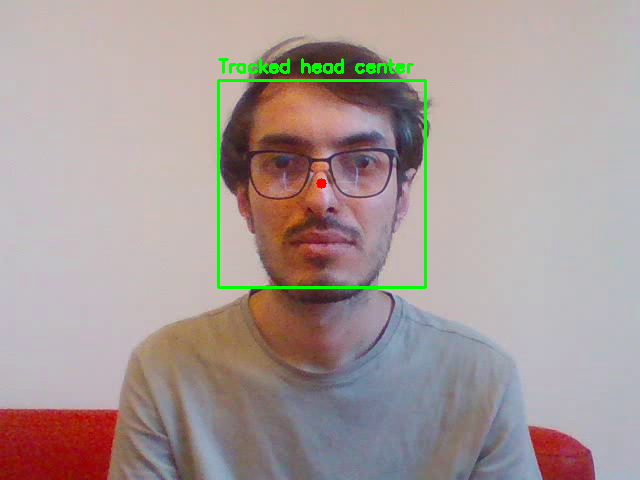

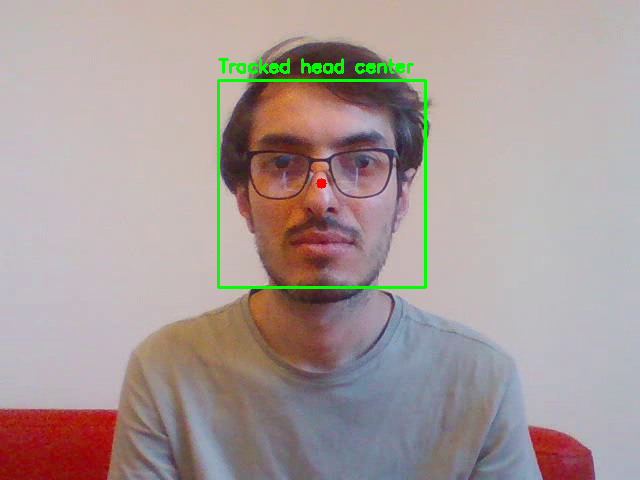

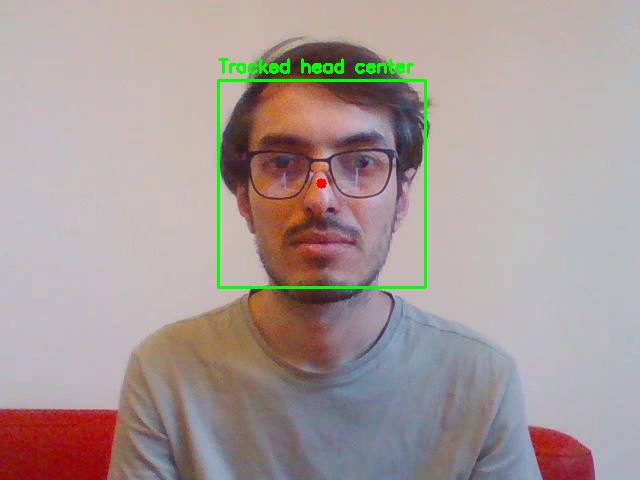

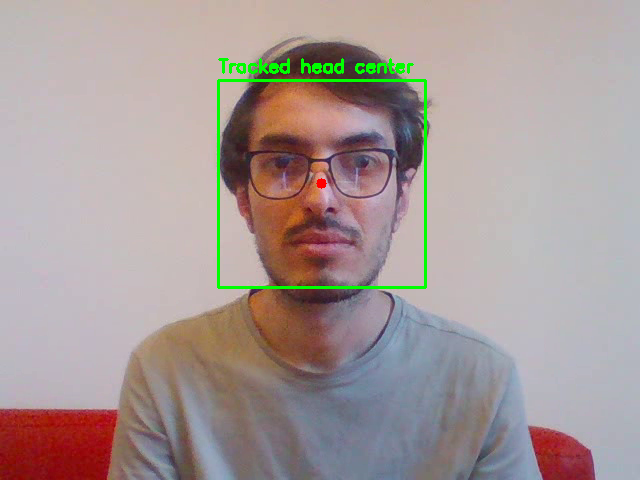


HEAD MOTION CLASSIFICATION RESULT
Video: reza_period_01_rppg_input_20260603_202324 (2).avi
Predicted class: zigzag
Confidence: 0.93

Motion details:
FPS: 30.00
Duration: 29.20 seconds
Valid tracking samples: 876
Valid tracking ratio: 1.000
Median face size: 204.00 px

Motion features:
x_amp: 0.1912
y_amp: 0.1728
total_amp: 0.2578
y_to_x_ratio: 0.9036
x_to_y_ratio: 1.1067
x_direction_changes: 0
y_direction_changes: 16
total_direction_changes: 16
path_length: 2.2094
used_trim: True


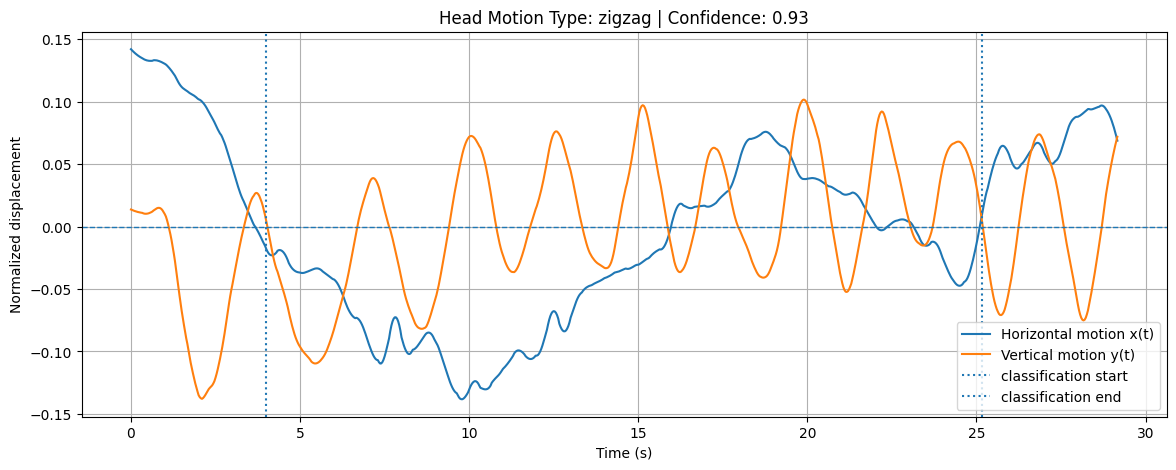


RUNNING SELECTED rPPG PIPELINE
Selected pipeline: ZIGZAG
Using video: reza_period_01_rppg_input_20260603_202324 (2).avi
Video FPS: 30.0
Extracted samples: 876
Duration: 29.17 s
Estimated FS: 30.0 Hz

Preview frames:
Green rectangle = face
Red rectangle = forehead
Blue rectangles = cheeks


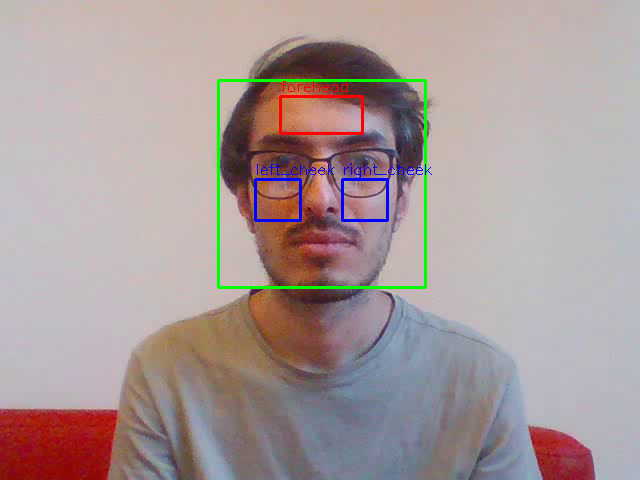

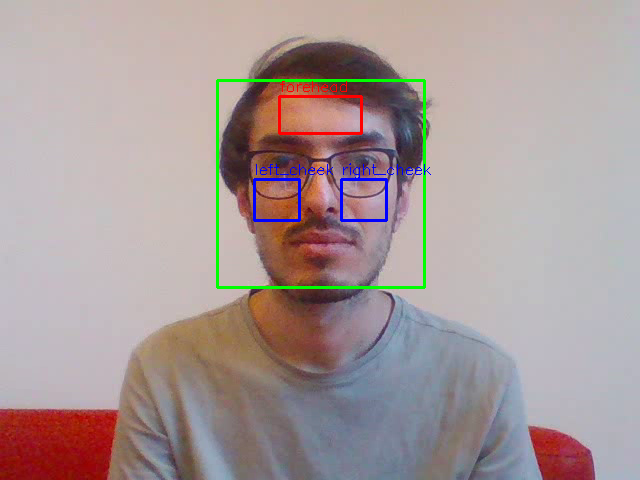

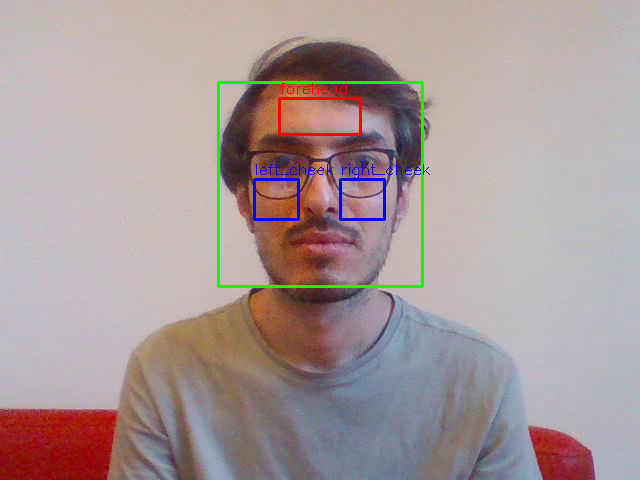

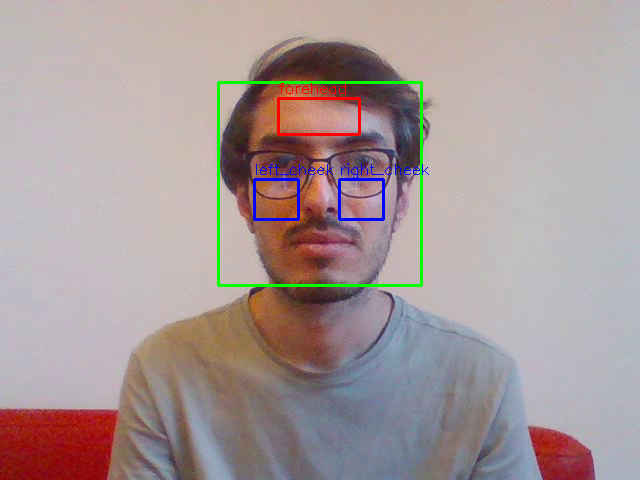

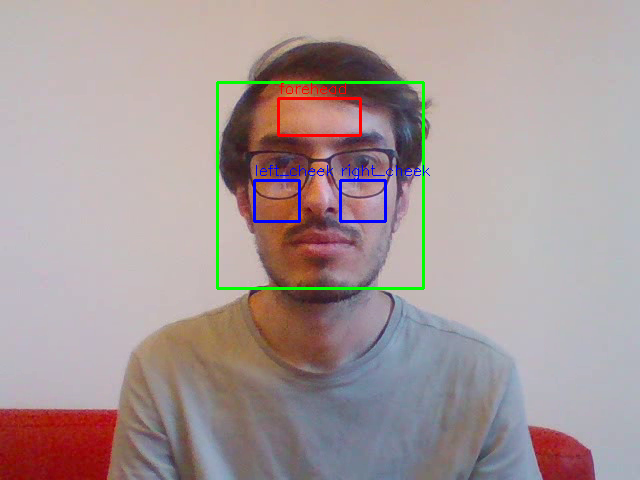


===== Smart Green-only rPPG Results =====
HR Green FFT: 69.96 bpm
HR Green Peak: 72.00 bpm

===== Smart POS rPPG Results =====
HR POS FFT: 70.07 bpm
HR POS Peak: 69.23 bpm

===== Consensus Result =====
Final Consensus HR: 70.02 bpm
Peak Guidance HR: 70.62 bpm
Motion Peak Correction Applied: False

Green FFT Debug
Full best: 70.2351373794199
Window HR: 69.9565232233615
Window median: 69.34592970562207
Window MAD: 1.3651633959706047
Reliability: 0.46591321730913526
Top FFT candidates:
1. 70.24 bpm | mag=12.740 | norm=1.000
2. 64.81 bpm | mag=8.558 | norm=0.672
3. 79.95 bpm | mag=6.037 | norm=0.474

POS FFT Debug
Full best: 70.2680094929091
Window HR: 70.07460326666842
Window median: 70.46585326618654
Window MAD: 0.8661088034997846
Reliability: 0.5814696167537187
Top FFT candidates:
1. 70.27 bpm | mag=86.094 | norm=1.000
2. 77.41 bpm | mag=38.734 | norm=0.450
3. 61.74 bpm | mag=35.737 | norm=0.415


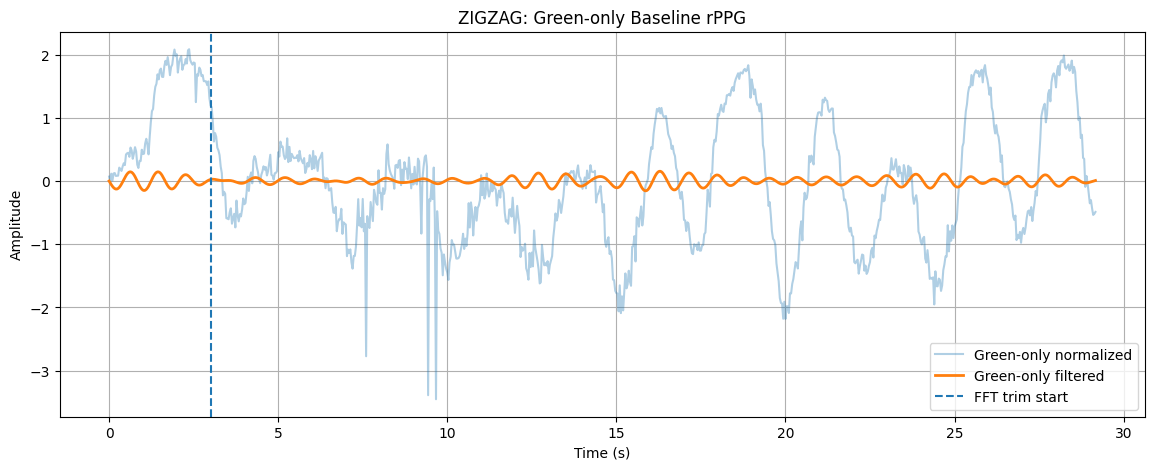

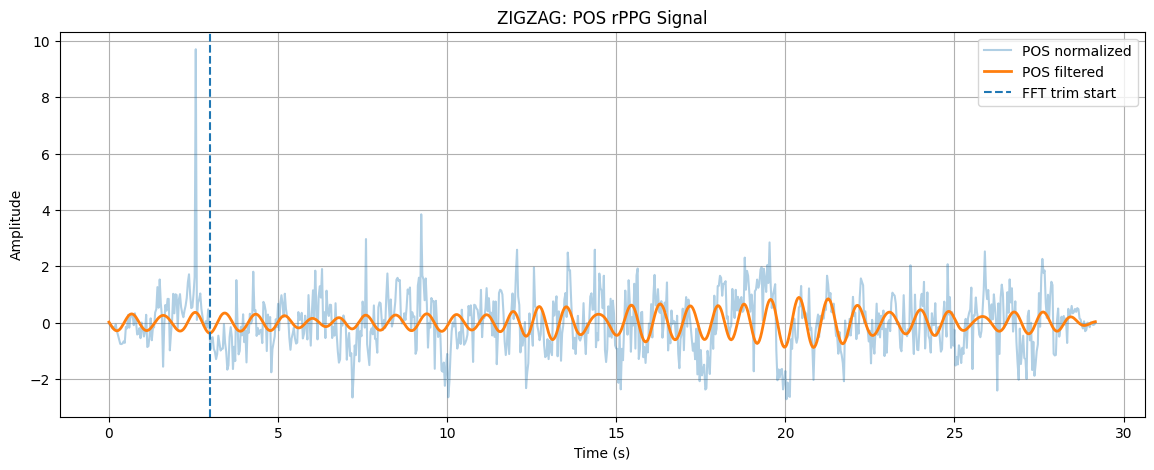

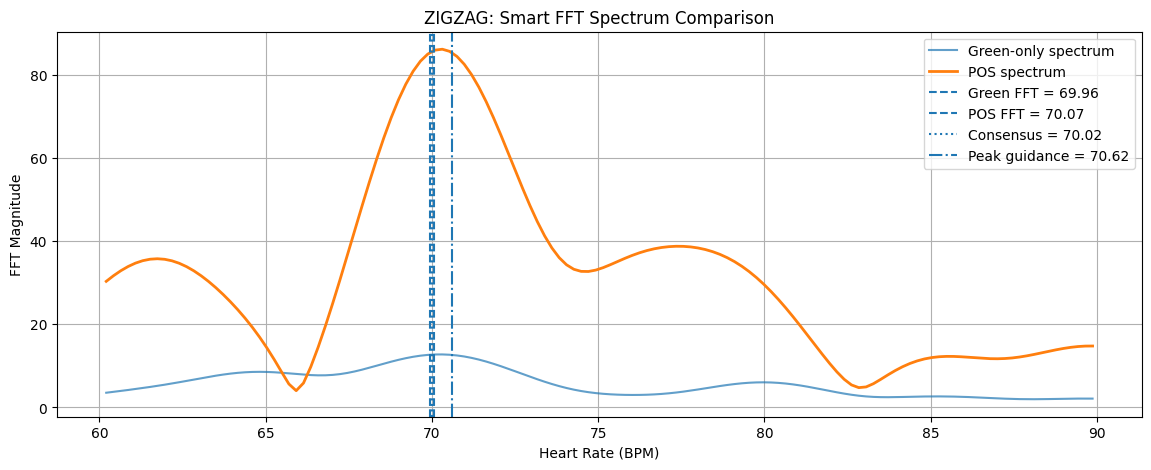

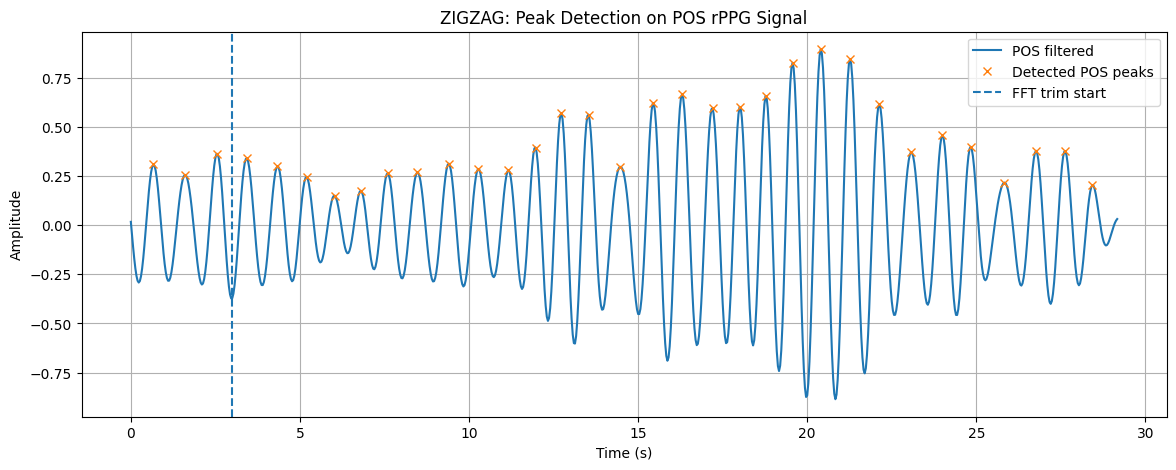


FINAL SUMMARY
Selected pipeline : ZIGZAG
Final HR           : 70.02 bpm
Sampling rate      : 30.00 Hz
Duration           : 29.17 s

  RESPIRATORY RATE FROM TACHOGRAM
[RR] Detected peaks     : 33
[RR] R-R intervals      : 32
[RR] Tachogram duration : 26.9 s
[RR] Mean R-R interval  : 867.7 ms  (69.1 BPM)

[RR] Welch dominant freq        : 0.1852 Hz
[RR] Respiratory Rate (Welch)   : 11.1 breaths/min
[RR] PSD peak sharpness         : 7.11  (>3 clean | <2 noisy)
[RR] Respiratory Rate (Hilbert) : 19.0 breaths/min
[RR] Method agreement diff      : 7.9  (POOR)

[RR] >>> FINAL RESPIRATORY RATE : 11.1 breaths/min <<<
[RR] Confidence                 : HIGH


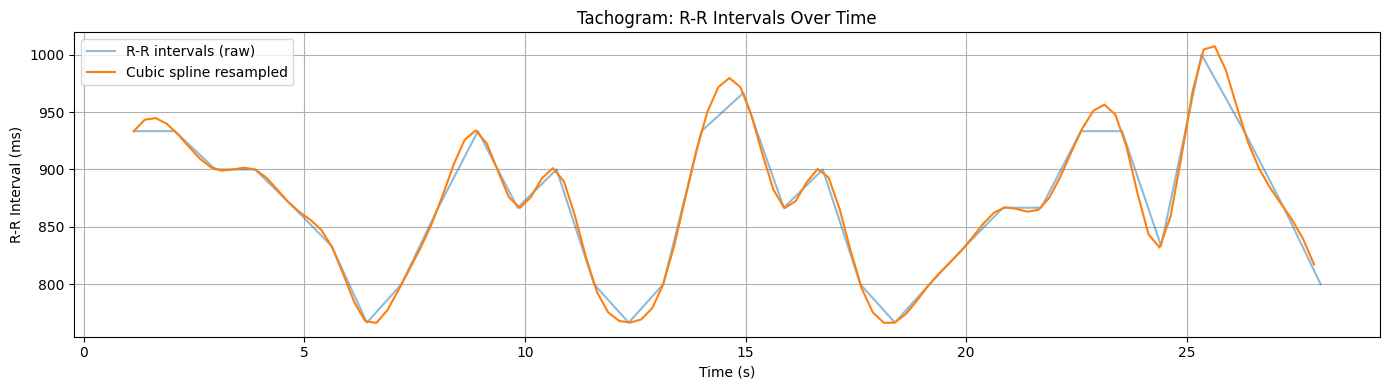

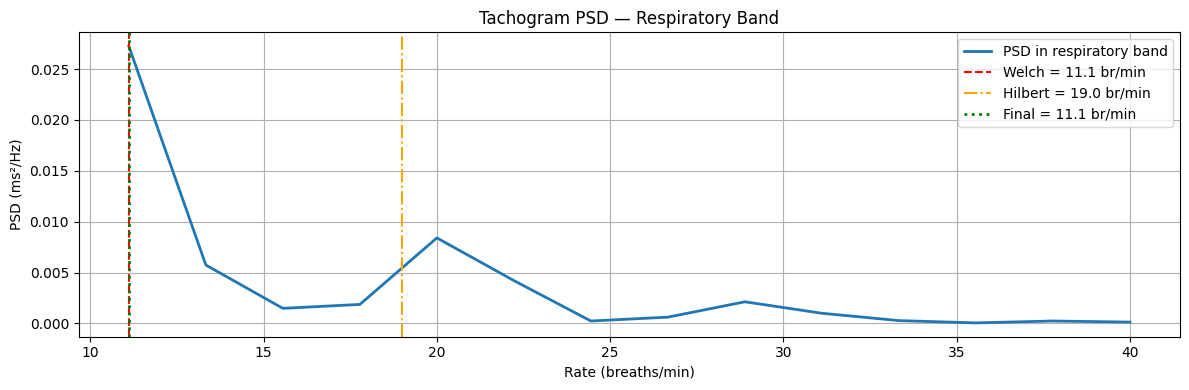

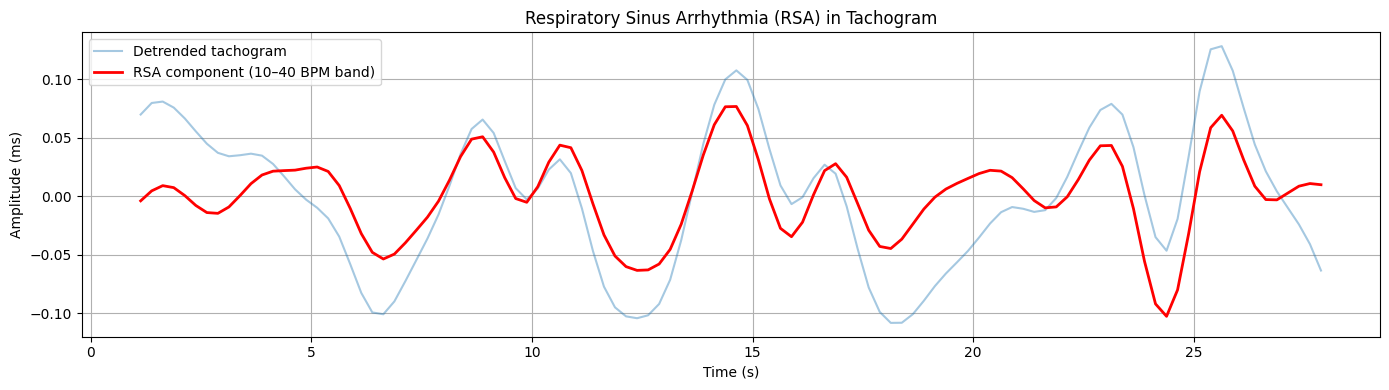


  PHYSIOLOGICAL SUMMARY
  Heart Rate        : 70.0 BPM
  Respiratory Rate  : 11.1 breaths/min
  HR / RR ratio     : 6.3  (normal resting ≈ 4–5)
  Motion class      : ZIGZAG

[Export] rppg_results dict ready for evaluation script.

  METRIC EVALUATION
  Upload the CMS50D CSV file for this video now.


Saving reza_period_01_cms50d_sync_data_20260603_202324.csv to reza_period_01_cms50d_sync_data_20260603_202324.csv
CSV loaded: reza_period_01_cms50d_sync_data_20260603_202324.csv
  Rows (clean)  : 876
  Format        : A (full — HR_FFT present)

  GT median      : 67.00 BPM
  GT stable end  : 66.00 BPM
  rPPG estimate  : 70.02 BPM

  Signed error   : +3.02 BPM  (overestimate)
  MAE            : 3.02 BPM
  MAPE           : 4.50 %
  Clinical check : PASS ✓

  HR_FFT stable   : 66.06 BPM
  HR_FFT MAE      : 3.194 BPM  (device-internal floor)

  HR from waveform: 69.23 BPM
  Waveform HR err : +2.23 BPM
  Perfusion Index : 50.72 %
  Pulse Amp CV    : 19.32 %

  SpO2 mean/std   : 97.86 / 0.35 %
  SpO2 range      : 97–98 %


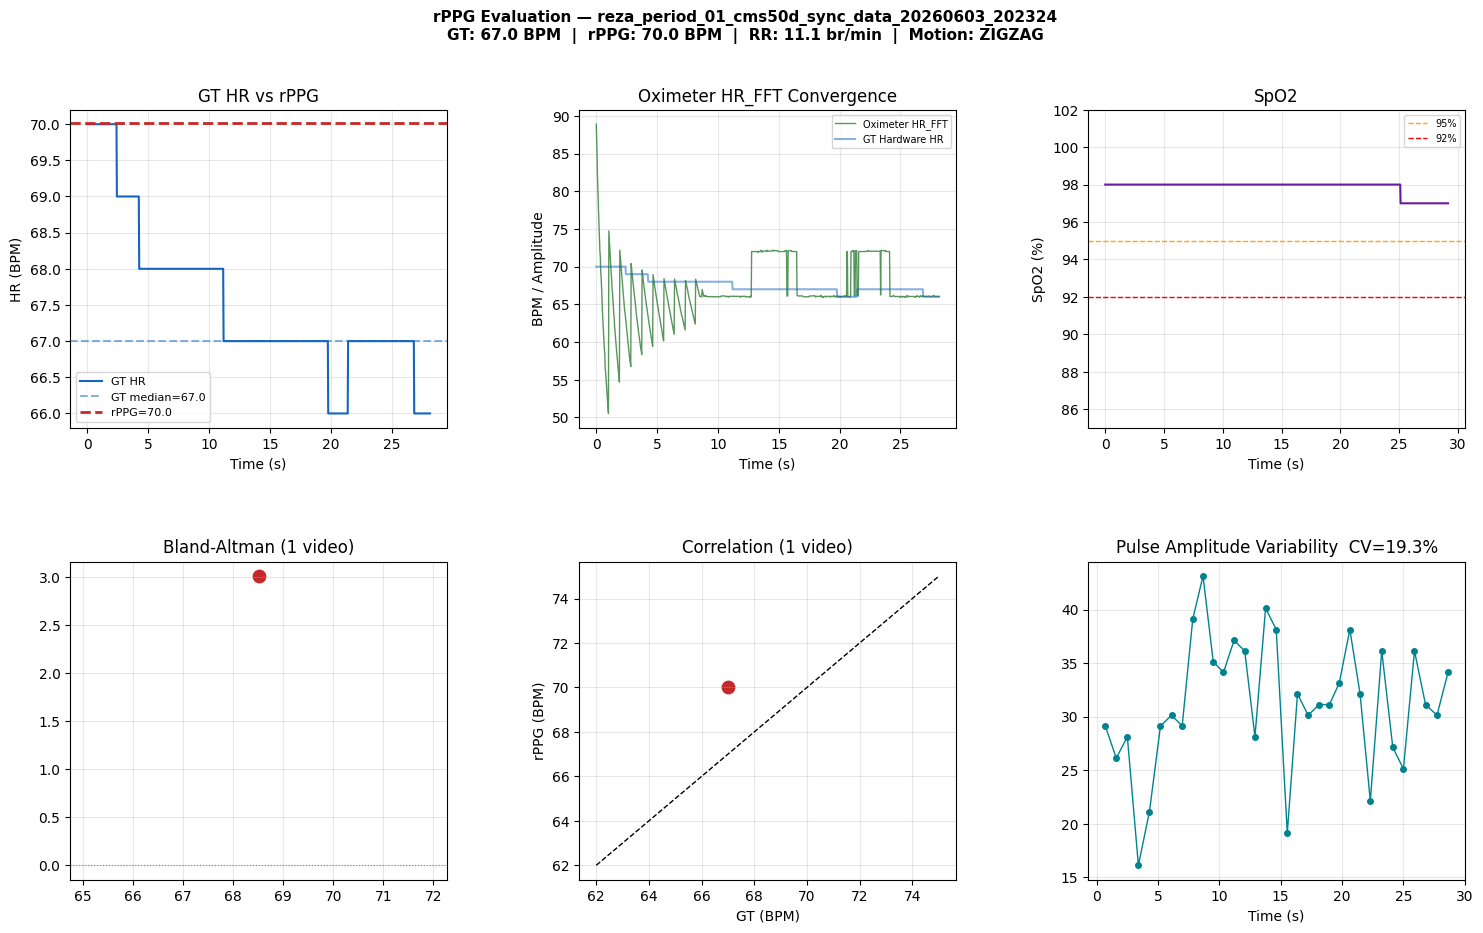


  Dashboard saved → rppg_evaluation_dashboard.png

  COMPLETE EVALUATION SUMMARY
  Subject                       : reza_period_01_cms50d_sync_data_20260603_202324
  Motion class                  : ZIGZAG
  GT median HR                  : 67.00 BPM
  GT stable end HR              : 66.00 BPM
  rPPG Consensus HR             : 70.02 BPM
  Signed error                  : +3.02 BPM
  MAE                           : 3.02 BPM
  MAPE                          : 4.50 %
  Clinical pass                 : YES ✓
  Respiratory Rate              : 11.1 br/min
  Green reliability             : 0.466
  POS reliability               : 0.581
  SpO2 mean                     : 97.86 %
  HR from waveform              : 69.23 BPM
  Perfusion Index               : 50.72 %


In [ ]:
# ============================================================
# Unified Nearable rPPG Pipeline - Final Version
# Classification logic restored to the original working version.
# LEFT-RIGHT output is full: HR values + debug + plots.
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


from scipy import stats
from scipy.signal import butter, filtfilt, find_peaks, detrend, savgol_filter
from google.colab.patches import cv2_imshow
from google.colab import files


# ============================================================
# Global settings
# ============================================================

MIN_BPM = 60
MAX_BPM = 90

TRIM_START_SECONDS = 3.0
POS_WINDOW_SECONDS = 1.6

WINDOW_SECONDS = 12.0
WINDOW_STEP_SECONDS = 2.0

FFT_TOP_N_PEAKS = 8
FFT_ZERO_PADDING_FACTOR = 8

SHOW_HEAD_TRACKING_PREVIEW = True
SHOW_RPPG_PREVIEW = True
MAX_PREVIEW_FRAMES = 5


# ============================================================
# Basic signal functions
# ============================================================

def normalize_signal(signal):
    signal = np.asarray(signal, dtype=float)
    mean = np.mean(signal)
    std = np.std(signal)

    if std < 1e-8:
        return signal - mean

    return (signal - mean) / std


def bandpass_filter(signal, fs, min_bpm=60, max_bpm=90, order=4):
    signal = np.asarray(signal, dtype=float)

    low_hz = min_bpm / 60.0
    high_hz = max_bpm / 60.0

    try:
        b, a = butter(order, [low_hz, high_hz], btype="bandpass", fs=fs)
        padlen = 3 * max(len(a), len(b))

        if len(signal) <= padlen:
            return signal

        return filtfilt(b, a, signal)

    except Exception as e:
        print("[Filter warning]", e)
        return signal


def trim_signal_start(signal, fs, trim_start_seconds=3.0):
    signal = np.asarray(signal, dtype=float)
    trim_samples = int(trim_start_seconds * fs)

    if len(signal) > trim_samples + int(fs * 6):
        return signal[trim_samples:]

    return signal


def next_power_of_two(n):
    return int(2 ** np.ceil(np.log2(max(1, n))))


def parabolic_interpolation(y, index):
    if index <= 0 or index >= len(y) - 1:
        return 0.0

    y0 = y[index - 1]
    y1 = y[index]
    y2 = y[index + 1]

    denominator = y0 - 2.0 * y1 + y2

    if abs(denominator) < 1e-12:
        return 0.0

    delta = 0.5 * (y0 - y2) / denominator
    delta = float(np.clip(delta, -0.5, 0.5))

    return delta


# ============================================================
# FFT functions
# ============================================================

def compute_fft_spectrum(
    signal,
    fs,
    min_bpm=60,
    max_bpm=90,
    trim_start_seconds=3.0,
    zero_padding_factor=8
):
    signal = np.asarray(signal, dtype=float)
    signal = trim_signal_start(signal, fs, trim_start_seconds)

    if len(signal) < int(fs * 6):
        return None, None

    signal = signal - np.mean(signal)
    signal = signal * np.hanning(len(signal))

    n_fft = next_power_of_two(len(signal)) * zero_padding_factor

    freqs = np.fft.rfftfreq(n_fft, d=1.0 / fs)
    spectrum = np.abs(np.fft.rfft(signal, n=n_fft))

    bpm_axis = freqs * 60.0
    mask = (bpm_axis >= min_bpm) & (bpm_axis <= max_bpm)

    if not np.any(mask):
        return None, None

    return bpm_axis[mask], spectrum[mask]


def refined_peak_bpm(bpm_axis, spectrum, peak_index):
    if bpm_axis is None or spectrum is None:
        return None

    if len(bpm_axis) < 2:
        return float(bpm_axis[peak_index])

    bpm_step = bpm_axis[1] - bpm_axis[0]

    safe_spectrum = np.maximum(spectrum, 1e-12)
    log_spectrum = np.log(safe_spectrum)

    delta = parabolic_interpolation(log_spectrum, peak_index)
    refined_bpm = bpm_axis[peak_index] + delta * bpm_step

    return float(refined_bpm)


def get_fft_candidates(
    signal,
    fs,
    min_bpm=60,
    max_bpm=90,
    trim_start_seconds=3.0,
    top_n_peaks=8
):
    bpm_axis, spectrum = compute_fft_spectrum(
        signal,
        fs,
        min_bpm=min_bpm,
        max_bpm=max_bpm,
        trim_start_seconds=trim_start_seconds,
        zero_padding_factor=FFT_ZERO_PADDING_FACTOR
    )

    if bpm_axis is None or spectrum is None or len(spectrum) == 0:
        return []

    max_mag = np.max(spectrum)

    if max_mag < 1e-8:
        return []

    peak_indices, _ = find_peaks(
        spectrum,
        distance=2,
        prominence=0.03 * max_mag
    )

    if len(peak_indices) == 0:
        peak_indices = np.array([int(np.argmax(spectrum))])

    peak_mag = spectrum[peak_indices]
    order = np.argsort(peak_mag)[::-1]
    order = order[:top_n_peaks]

    candidates = []

    for idx in order:
        peak_index = int(peak_indices[idx])
        bpm = refined_peak_bpm(bpm_axis, spectrum, peak_index)

        candidates.append({
            "bpm": float(bpm),
            "magnitude": float(spectrum[peak_index]),
            "norm_magnitude": float(spectrum[peak_index] / max_mag)
        })

    return candidates


def estimate_windowed_fft(
    signal,
    fs,
    min_bpm=60,
    max_bpm=90,
    trim_start_seconds=3.0,
    window_seconds=12.0,
    step_seconds=2.0
):
    signal = np.asarray(signal, dtype=float)
    signal = trim_signal_start(signal, fs, trim_start_seconds)

    window_len = int(window_seconds * fs)
    step_len = int(step_seconds * fs)

    if len(signal) < window_len:
        return []

    estimates = []

    for start in range(0, len(signal) - window_len + 1, step_len):
        end = start + window_len
        segment = signal[start:end]

        bpm_axis, spectrum = compute_fft_spectrum(
            segment,
            fs,
            min_bpm=min_bpm,
            max_bpm=max_bpm,
            trim_start_seconds=0.0,
            zero_padding_factor=FFT_ZERO_PADDING_FACTOR
        )

        if bpm_axis is None or spectrum is None or len(spectrum) == 0:
            continue

        max_mag = np.max(spectrum)
        mean_mag = np.mean(spectrum) + 1e-8

        if max_mag < 1e-8:
            continue

        best_idx = int(np.argmax(spectrum))
        best_bpm = refined_peak_bpm(bpm_axis, spectrum, best_idx)
        quality = float(max_mag / mean_mag)

        estimates.append({
            "bpm": float(best_bpm),
            "quality": quality,
            "start_sec": start / fs,
            "end_sec": end / fs
        })

    return estimates


def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    if len(values) == 0:
        return None

    if np.sum(weights) < 1e-8:
        return float(np.mean(values))

    return float(np.sum(values * weights) / np.sum(weights))


def robust_window_hr(window_estimates):
    if len(window_estimates) == 0:
        return None, None, None

    bpms = np.asarray([item["bpm"] for item in window_estimates], dtype=float)
    qualities = np.asarray([item["quality"] for item in window_estimates], dtype=float)

    median_hr = float(np.median(bpms))
    mad = float(np.median(np.abs(bpms - median_hr)))

    if len(bpms) >= 3:
        keep_mask = np.abs(bpms - median_hr) <= max(4.0, 1.5 * mad)
        kept_bpms = bpms[keep_mask]
        kept_qualities = qualities[keep_mask]
    else:
        kept_bpms = bpms
        kept_qualities = qualities

    if len(kept_bpms) == 0:
        kept_bpms = bpms
        kept_qualities = qualities

    stable_hr = weighted_mean(kept_bpms, kept_qualities)

    return stable_hr, median_hr, mad


def summarize_channel_fft(
    signal,
    fs,
    min_bpm=60,
    max_bpm=90,
    trim_start_seconds=3.0,
    top_n_peaks=8,
    window_seconds=12.0,
    step_seconds=2.0
):
    candidates = get_fft_candidates(
        signal,
        fs,
        min_bpm=min_bpm,
        max_bpm=max_bpm,
        trim_start_seconds=trim_start_seconds,
        top_n_peaks=top_n_peaks
    )

    window_estimates = estimate_windowed_fft(
        signal,
        fs,
        min_bpm=min_bpm,
        max_bpm=max_bpm,
        trim_start_seconds=trim_start_seconds,
        window_seconds=window_seconds,
        step_seconds=step_seconds
    )

    full_best = None
    if len(candidates) > 0:
        full_best = candidates[0]["bpm"]

    window_hr, window_median, window_mad = robust_window_hr(window_estimates)

    if window_hr is None:
        window_hr = full_best

    window_qualities = [item["quality"] for item in window_estimates]

    if window_mad is None:
        stability_score = 0.0
    else:
        stability_score = 1.0 / (1.0 + window_mad)

    if len(window_qualities) > 0:
        quality_score = float(np.median(window_qualities))
    else:
        quality_score = 0.0

    if len(candidates) >= 2:
        peak_ratio = candidates[0]["magnitude"] / (candidates[1]["magnitude"] + 1e-8)
    else:
        peak_ratio = 1.0

    reliability = float(
        0.45 * stability_score +
        0.35 * min(quality_score / 5.0, 1.0) +
        0.20 * min(peak_ratio / 2.0, 1.0)
    )

    return {
        "candidates": candidates,
        "window_estimates": window_estimates,
        "full_best": full_best,
        "window_hr": window_hr,
        "window_median": window_median,
        "window_mad": window_mad,
        "quality_score": quality_score,
        "peak_ratio": peak_ratio,
        "reliability": reliability
    }


def build_consensus_hr(green_info, pos_info):
    green_window = green_info["window_hr"]
    pos_window = pos_info["window_hr"]
    green_full = green_info["full_best"]
    pos_full = pos_info["full_best"]

    values = []
    weights = []

    if green_window is not None:
        values.append(green_window)
        weights.append(1.0 + green_info["reliability"])

    if pos_window is not None:
        values.append(pos_window)
        weights.append(1.0 + pos_info["reliability"])

    if green_full is not None:
        values.append(green_full)
        weights.append(0.45 + 0.5 * green_info["reliability"])

    if pos_full is not None:
        values.append(pos_full)
        weights.append(0.45 + 0.5 * pos_info["reliability"])

    if len(values) == 0:
        return None

    if green_window is not None and pos_window is not None:
        diff = abs(green_window - pos_window)

        if diff <= 4.0:
            return weighted_mean(
                [green_window, pos_window],
                [1.0 + green_info["reliability"], 1.0 + pos_info["reliability"]]
            )

        if green_info["reliability"] > pos_info["reliability"] + 0.15:
            return float(green_window)

        if pos_info["reliability"] > green_info["reliability"] + 0.15:
            return float(pos_window)

    return weighted_mean(values, weights)


def choose_candidate_near_consensus(channel_info, consensus_hr):
    if consensus_hr is None:
        if channel_info["window_hr"] is not None:
            return channel_info["window_hr"]
        return channel_info["full_best"]

    candidate_bpms = []
    candidate_weights = []

    for candidate in channel_info["candidates"]:
        candidate_bpms.append(candidate["bpm"])
        candidate_weights.append(candidate["norm_magnitude"])

    if channel_info["window_hr"] is not None:
        candidate_bpms.append(channel_info["window_hr"])
        candidate_weights.append(0.95)

    if channel_info["full_best"] is not None:
        candidate_bpms.append(channel_info["full_best"])
        candidate_weights.append(0.75)

    if len(candidate_bpms) == 0:
        return consensus_hr

    candidate_bpms = np.asarray(candidate_bpms, dtype=float)
    candidate_weights = np.asarray(candidate_weights, dtype=float)

    distances = np.abs(candidate_bpms - consensus_hr)
    scores = distances - 2.0 * candidate_weights

    best_idx = int(np.argmin(scores))
    selected = float(candidate_bpms[best_idx])

    if abs(selected - consensus_hr) > 6.0:
        selected = float(consensus_hr)

    return selected


def estimate_smart_fft_pair(
    green_signal,
    pos_signal,
    fs,
    min_bpm=60,
    max_bpm=90,
    trim_start_seconds=3.0
):
    green_info = summarize_channel_fft(
        green_signal,
        fs,
        min_bpm=min_bpm,
        max_bpm=max_bpm,
        trim_start_seconds=trim_start_seconds,
        top_n_peaks=FFT_TOP_N_PEAKS,
        window_seconds=WINDOW_SECONDS,
        step_seconds=WINDOW_STEP_SECONDS
    )

    pos_info = summarize_channel_fft(
        pos_signal,
        fs,
        min_bpm=min_bpm,
        max_bpm=max_bpm,
        trim_start_seconds=trim_start_seconds,
        top_n_peaks=FFT_TOP_N_PEAKS,
        window_seconds=WINDOW_SECONDS,
        step_seconds=WINDOW_STEP_SECONDS
    )

    consensus_hr = build_consensus_hr(green_info, pos_info)

    green_hr = choose_candidate_near_consensus(green_info, consensus_hr)
    pos_hr = choose_candidate_near_consensus(pos_info, consensus_hr)

    return green_hr, pos_hr, consensus_hr, green_info, pos_info


def estimate_hr_peaks(signal, fs, min_bpm=60, max_bpm=90):
    signal = np.asarray(signal, dtype=float)

    if len(signal) < int(fs * 6):
        return None

    signal = signal - np.mean(signal)

    min_distance = max(1, int(fs * 60.0 / max_bpm))
    prominence = max(0.35 * np.std(signal), 0.15)

    peaks, _ = find_peaks(
        signal,
        distance=min_distance,
        prominence=prominence
    )

    if len(peaks) < 2:
        return None

    intervals = np.diff(peaks) / fs
    bpm_values = 60.0 / intervals

    bpm_values = bpm_values[
        (bpm_values >= min_bpm) & (bpm_values <= max_bpm)
    ]

    if len(bpm_values) == 0:
        return None

    return float(np.median(bpm_values))


# ============================================================
# Correction rules
# ============================================================

def adaptive_final_correction(
    green_info,
    pos_info,
    hr_green_fft,
    hr_pos_fft,
    hr_consensus,
    hr_green_peak,
    hr_pos_peak
):
    def get_strong_high_candidate(channel_info, low_bpm=78.0, high_bpm=86.5, min_norm=0.70):
        valid_candidates = []

        for candidate in channel_info["candidates"]:
            bpm = float(candidate["bpm"])
            norm = float(candidate["norm_magnitude"])

            if low_bpm <= bpm <= high_bpm and norm >= min_norm:
                valid_candidates.append(candidate)

        if len(valid_candidates) == 0:
            return None

        valid_candidates = sorted(valid_candidates, key=lambda c: c["norm_magnitude"], reverse=True)
        return valid_candidates[0]

    def is_value_high(value, low_bpm=78.0, high_bpm=86.5):
        if value is None:
            return False
        return low_bpm <= value <= high_bpm

    def get_current_consensus(hr_green_fft, hr_pos_fft, hr_consensus):
        current_values = [
            value for value in [hr_green_fft, hr_pos_fft, hr_consensus]
            if value is not None
        ]

        if len(current_values) == 0:
            return None

        return float(np.median(current_values))

    peak_guidance_hr = None

    green_high_candidate = get_strong_high_candidate(green_info)
    pos_high_candidate = get_strong_high_candidate(pos_info)

    green_full_is_high = is_value_high(green_info["full_best"])
    pos_full_is_high = is_value_high(pos_info["full_best"])
    pos_window_is_high = is_value_high(pos_info["window_hr"])
    pos_median_is_high = is_value_high(pos_info["window_median"])

    current_consensus = get_current_consensus(hr_green_fft, hr_pos_fft, hr_consensus)

    if pos_high_candidate is not None and current_consensus is not None:
        pos_high_bpm = float(pos_high_candidate["bpm"])
        pos_high_norm = float(pos_high_candidate["norm_magnitude"])

        pos_has_high_main_support = (
            pos_full_is_high or
            pos_window_is_high or
            pos_median_is_high
        )

        pos_has_strong_high_evidence = (
            pos_high_norm >= 0.70 and
            pos_high_bpm - current_consensus >= 6.0 and
            pos_has_high_main_support
        )

        green_is_not_strongly_opposing = True

        if green_high_candidate is not None:
            green_high_bpm = float(green_high_candidate["bpm"])
            if abs(green_high_bpm - pos_high_bpm) > 7.0:
                green_is_not_strongly_opposing = False

        peak_does_not_strongly_reject_high = True

        if hr_green_peak is not None and hr_pos_peak is not None:
            peak_guidance_temp = float(np.median([hr_green_peak, hr_pos_peak]))

            if peak_guidance_temp < 74.0 and pos_high_bpm - peak_guidance_temp > 8.0:
                peak_does_not_strongly_reject_high = False

        if (
            pos_has_strong_high_evidence and
            green_is_not_strongly_opposing and
            peak_does_not_strongly_reject_high
        ):
            hr_green_fft = pos_high_bpm
            hr_pos_fft = pos_high_bpm
            hr_consensus = pos_high_bpm
            peak_guidance_hr = None

            return hr_green_fft, hr_pos_fft, hr_consensus, peak_guidance_hr

    if green_high_candidate is not None and pos_high_candidate is not None:
        green_high_bpm = float(green_high_candidate["bpm"])
        pos_high_bpm = float(pos_high_candidate["bpm"])

        high_candidate_diff = abs(green_high_bpm - pos_high_bpm)
        high_candidate_consensus = float(np.median([green_high_bpm, pos_high_bpm]))

        current_consensus = get_current_consensus(hr_green_fft, hr_pos_fft, hr_consensus)
        high_full_support = green_full_is_high or pos_full_is_high

        if (
            high_candidate_diff <= 4.0 and
            current_consensus is not None and
            high_candidate_consensus - current_consensus >= 5.0 and
            high_full_support
        ):
            hr_green_fft = green_high_bpm
            hr_pos_fft = pos_high_bpm
            hr_consensus = float(np.median([hr_green_fft, hr_pos_fft]))
            peak_guidance_hr = None

            return hr_green_fft, hr_pos_fft, hr_consensus, peak_guidance_hr

    if hr_green_peak is not None and hr_pos_peak is not None:
        peak_diff = abs(hr_green_peak - hr_pos_peak)

        if peak_diff <= 3.0:
            peak_guidance_hr = float(np.median([hr_green_peak, hr_pos_peak]))

            if hr_green_fft is not None and abs(hr_green_fft - peak_guidance_hr) > 2.0:
                hr_green_fft = peak_guidance_hr

            if hr_pos_fft is not None and abs(hr_pos_fft - peak_guidance_hr) > 2.0:
                hr_pos_fft = peak_guidance_hr

            if hr_green_fft is not None and hr_pos_fft is not None:
                hr_consensus = float(np.median([hr_green_fft, hr_pos_fft]))

        else:
            peak_guidance_hr = float(np.median([hr_green_peak, hr_pos_peak]))

    elif hr_pos_peak is not None:
        peak_guidance_hr = float(hr_pos_peak)

    elif hr_green_peak is not None:
        peak_guidance_hr = float(hr_green_peak)

    return hr_green_fft, hr_pos_fft, hr_consensus, peak_guidance_hr


def motion_peak_guidance_correction(
    hr_green_fft,
    hr_pos_fft,
    hr_consensus,
    peak_guidance_hr
):
    if peak_guidance_hr is None:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    if hr_green_fft is None or hr_pos_fft is None or hr_consensus is None:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    if not (70.0 <= peak_guidance_hr <= 82.0):
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    both_fft_below_guidance = (
        hr_green_fft < peak_guidance_hr - 4.0 and
        hr_pos_fft < peak_guidance_hr - 4.0
    )

    consensus_far_below_guidance = hr_consensus < peak_guidance_hr - 5.0

    if both_fft_below_guidance and consensus_far_below_guidance:
        corrected_hr = float(peak_guidance_hr)
        return corrected_hr, corrected_hr, corrected_hr, True

    return hr_green_fft, hr_pos_fft, hr_consensus, False


def left_right_candidate_guidance_correction(
    green_info,
    pos_info,
    hr_green_fft,
    hr_pos_fft,
    hr_consensus,
    peak_guidance_hr
):
    if peak_guidance_hr is None:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    if hr_green_fft is None or hr_pos_fft is None or hr_consensus is None:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    if not (70.0 <= peak_guidance_hr <= 80.5):
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    consensus_too_low = hr_consensus < peak_guidance_hr - 4.0

    if not consensus_too_low:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    def find_candidate_near_guidance(channel_info, guidance_hr, tolerance=3.0, min_norm=0.40):
        valid_candidates = []

        for candidate in channel_info["candidates"]:
            bpm = float(candidate["bpm"])
            norm = float(candidate["norm_magnitude"])

            if abs(bpm - guidance_hr) <= tolerance and norm >= min_norm:
                valid_candidates.append(candidate)

        if len(valid_candidates) == 0:
            return None

        valid_candidates = sorted(
            valid_candidates,
            key=lambda c: (
                abs(float(c["bpm"]) - guidance_hr),
                -float(c["norm_magnitude"])
            )
        )

        return valid_candidates[0]

    green_candidate = find_candidate_near_guidance(green_info, peak_guidance_hr)
    pos_candidate = find_candidate_near_guidance(pos_info, peak_guidance_hr)

    if green_candidate is not None and pos_candidate is not None:
        green_bpm = float(green_candidate["bpm"])
        pos_bpm = float(pos_candidate["bpm"])

        if abs(green_bpm - pos_bpm) <= 3.0:
            corrected_hr = float(np.median([green_bpm, pos_bpm, peak_guidance_hr]))
            return corrected_hr, corrected_hr, corrected_hr, True

    if pos_candidate is not None:
        pos_bpm = float(pos_candidate["bpm"])
        pos_norm = float(pos_candidate["norm_magnitude"])

        if pos_norm >= 0.55 and abs(pos_bpm - peak_guidance_hr) <= 3.0:
            corrected_hr = float(np.median([pos_bpm, peak_guidance_hr]))
            return corrected_hr, corrected_hr, corrected_hr, True

    return hr_green_fft, hr_pos_fft, hr_consensus, False


def left_right_low_lock_rescue(
    green_info,
    pos_info,
    hr_green_fft,
    hr_pos_fft,
    hr_consensus,
    peak_guidance_hr
):
    if hr_consensus is None:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    if hr_consensus >= 73.5:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    def get_high_candidate(channel_info, low_bpm=77.0, high_bpm=82.5, min_norm=0.45):
        valid_candidates = []

        for candidate in channel_info["candidates"]:
            bpm = float(candidate["bpm"])
            norm = float(candidate["norm_magnitude"])

            if low_bpm <= bpm <= high_bpm and norm >= min_norm:
                valid_candidates.append(candidate)

        if len(valid_candidates) == 0:
            return None

        valid_candidates = sorted(
            valid_candidates,
            key=lambda c: (
                -float(c["norm_magnitude"]),
                abs(float(c["bpm"]) - 79.5)
            )
        )

        return valid_candidates[0]

    green_high = get_high_candidate(green_info)
    pos_high = get_high_candidate(pos_info)

    candidates = []

    if green_high is not None:
        candidates.append(float(green_high["bpm"]))

    if pos_high is not None:
        candidates.append(float(pos_high["bpm"]))

    if len(candidates) == 0:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    if len(candidates) >= 2:
        corrected_hr = float(np.median(candidates))

        if corrected_hr - hr_consensus >= 5.0:
            return corrected_hr, corrected_hr, corrected_hr, True

    if green_high is not None:
        green_bpm = float(green_high["bpm"])
        green_norm = float(green_high["norm_magnitude"])

        if green_norm >= 0.65 and green_bpm - hr_consensus >= 5.0:
            corrected_hr = green_bpm
            return corrected_hr, corrected_hr, corrected_hr, True

    if pos_high is not None:
        pos_bpm = float(pos_high["bpm"])
        pos_norm = float(pos_high["norm_magnitude"])

        if pos_norm >= 0.70 and pos_bpm - hr_consensus >= 5.0:
            corrected_hr = pos_bpm
            return corrected_hr, corrected_hr, corrected_hr, True

    return hr_green_fft, hr_pos_fft, hr_consensus, False


def left_right_high_hr_rescue(
    green_info,
    pos_info,
    hr_green_fft,
    hr_pos_fft,
    hr_consensus,
    peak_guidance_hr
):
    if hr_consensus is None:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    if not (78.0 <= hr_consensus <= 82.5):
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    def get_very_high_candidate(channel_info, low_bpm=86.0, high_bpm=90.0, min_norm=0.35):
        valid_candidates = []

        for candidate in channel_info["candidates"]:
            bpm = float(candidate["bpm"])
            norm = float(candidate["norm_magnitude"])

            if low_bpm <= bpm <= high_bpm and norm >= min_norm:
                valid_candidates.append(candidate)

        if len(valid_candidates) == 0:
            return None

        valid_candidates = sorted(
            valid_candidates,
            key=lambda c: (
                -float(c["norm_magnitude"]),
                abs(float(c["bpm"]) - 88.0)
            )
        )

        return valid_candidates[0]

    green_very_high = get_very_high_candidate(
        green_info,
        low_bpm=86.0,
        high_bpm=90.0,
        min_norm=0.55
    )

    pos_very_high = get_very_high_candidate(
        pos_info,
        low_bpm=86.0,
        high_bpm=90.0,
        min_norm=0.35
    )

    if green_very_high is None and pos_very_high is None:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    high_candidates = []

    if green_very_high is not None:
        high_candidates.append(float(green_very_high["bpm"]))

    if pos_very_high is not None:
        high_candidates.append(float(pos_very_high["bpm"]))

    corrected_hr = float(np.median(high_candidates))

    if green_very_high is not None and pos_very_high is not None:
        green_bpm = float(green_very_high["bpm"])
        pos_bpm = float(pos_very_high["bpm"])

        if abs(green_bpm - pos_bpm) <= 3.0 and corrected_hr - hr_consensus >= 4.0:
            return corrected_hr, corrected_hr, corrected_hr, True

    if green_very_high is not None:
        green_bpm = float(green_very_high["bpm"])
        green_norm = float(green_very_high["norm_magnitude"])

        if green_norm >= 0.65 and green_bpm - hr_consensus >= 5.0:
            return green_bpm, green_bpm, green_bpm, True

    return hr_green_fft, hr_pos_fft, hr_consensus, False


# ============================================================
# ROI functions
# ============================================================

def keep_roi_inside_frame(roi, frame_shape):
    x, y, w, h = roi
    height, width = frame_shape[:2]

    x = max(0, x)
    y = max(0, y)
    w = max(1, min(w, width - x))
    h = max(1, min(h, height - y))

    return x, y, w, h


def get_multi_rois(face, frame_shape):
    x, y, w, h = face

    rois = {}

    rois["forehead"] = (
        x + int(0.30 * w),
        y + int(0.08 * h),
        int(0.40 * w),
        int(0.18 * h)
    )

    rois["left_cheek"] = (
        x + int(0.18 * w),
        y + int(0.48 * h),
        int(0.22 * w),
        int(0.20 * h)
    )

    rois["right_cheek"] = (
        x + int(0.60 * w),
        y + int(0.48 * h),
        int(0.22 * w),
        int(0.20 * h)
    )

    for key in rois:
        rois[key] = keep_roi_inside_frame(rois[key], frame_shape)

    return rois


def mean_rgb_from_roi(frame, roi):
    x, y, w, h = roi
    roi_frame = frame[y:y+h, x:x+w, :]

    if roi_frame.size == 0:
        return None

    mean_bgr = np.mean(roi_frame.reshape(-1, 3), axis=0)
    mean_rgb = mean_bgr[::-1]

    return mean_rgb


# ============================================================
# POS algorithm
# ============================================================

def pos_rppg(rgb_signal, fs, window_seconds=1.6):
    rgb_signal = np.asarray(rgb_signal, dtype=float)
    n = rgb_signal.shape[0]

    if n < int(window_seconds * fs):
        return np.zeros(n)

    window_length = int(window_seconds * fs)
    h = np.zeros(n)

    for start in range(0, n - window_length + 1):
        end = start + window_length
        C = rgb_signal[start:end, :].T

        mean_color = np.mean(C, axis=1, keepdims=True)
        mean_color[mean_color == 0] = 1e-8

        Cn = C / mean_color

        S1 = Cn[1, :] - Cn[2, :]
        S2 = Cn[1, :] + Cn[2, :] - 2 * Cn[0, :]

        std_s2 = np.std(S2)

        if std_s2 < 1e-8:
            alpha = 0.0
        else:
            alpha = np.std(S1) / std_s2

        H = S1 + alpha * S2
        H = H - np.mean(H)

        h[start:end] += H

    return h


# ============================================================
# Head motion classifier
# This section is copied from the original working Head Tracking code.
# Do not change it unless you intentionally want to re-tune classification.
# ============================================================

# =========================
# Settings
# =========================
SHOW_PREVIEW_FRAMES = True
DETECT_EVERY_N_FRAMES = 10
MIN_FACE_SIZE = (90, 90)

# Ignore beginning and ending parts for classification.
# This helps remove detector initialization drift and final tracking jumps.
CLASSIFICATION_TRIM_SECONDS = 4.0

# Stable thresholds
STABLE_X_THRESHOLD = 0.110
STABLE_Y_THRESHOLD = 0.110
STABLE_TOTAL_THRESHOLD = 0.140

# Drift-stable rule
# If there is no real repeated back-and-forth motion,
# classify as stable even if there is moderate tracking drift.
DRIFT_STABLE_TOTAL_THRESHOLD = 0.220
DRIFT_STABLE_MAX_X_CHANGES = 1
DRIFT_STABLE_MAX_Y_CHANGES = 2

# Left-right thresholds
LEFT_RIGHT_MIN_X = 0.120
LEFT_RIGHT_MAX_Y_TO_X_RATIO = 0.60
LEFT_RIGHT_MIN_X_CHANGES = 1

# Strong left-right rule
# This catches smooth left-right cases where x_direction_changes becomes zero.
STRONG_LEFT_RIGHT_MIN_X = 0.300
STRONG_LEFT_RIGHT_MAX_Y_TO_X_RATIO = 0.250

# Zigzag thresholds
ZIGZAG_MIN_X = 0.090
ZIGZAG_MIN_Y = 0.090
ZIGZAG_MIN_Y_TO_X_RATIO = 0.55
ZIGZAG_MIN_TOTAL_DIRECTION_CHANGES = 3

# Periodic/zigzag mixed motion thresholds
# This catches cases where x is dominant but y is oscillating repeatedly.
PERIODIC_ZIGZAG_MIN_X = 0.250
PERIODIC_ZIGZAG_MIN_Y = 0.060
PERIODIC_ZIGZAG_MIN_Y_CHANGES = 5
PERIODIC_ZIGZAG_MIN_TOTAL_CHANGES = 7

# Spike removal setting
SPIKE_Z_THRESHOLD = 3.5


# =========================
# Helper functions
# =========================
def largest_face(faces):
    if len(faces) == 0:
        return None

    faces = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)
    return faces[0]


def keep_box_inside_frame(box, frame_shape):
    x, y, w, h = box
    height, width = frame_shape[:2]

    x = max(0, int(x))
    y = max(0, int(y))
    w = max(1, min(int(w), width - x))
    h = max(1, min(int(h), height - y))

    return x, y, w, h


def expand_box(box, frame_shape, scale=1.15):
    x, y, w, h = box

    cx = x + w / 2.0
    cy = y + h / 2.0

    new_w = w * scale
    new_h = h * scale

    new_x = cx - new_w / 2.0
    new_y = cy - new_h / 2.0

    return keep_box_inside_frame((new_x, new_y, new_w, new_h), frame_shape)


def box_center(box):
    x, y, w, h = box
    return np.array([x + w / 2.0, y + h / 2.0], dtype=float)


def smooth_signal(signal):
    signal = np.asarray(signal, dtype=float)

    if len(signal) < 9:
        return signal

    window = min(21, len(signal))

    if window % 2 == 0:
        window -= 1

    if window < 7:
        return signal

    try:
        return savgol_filter(signal, window_length=window, polyorder=2)
    except Exception:
        return signal


def remove_spikes(signal, z_threshold=3.5):
    signal = np.asarray(signal, dtype=float)

    if len(signal) < 9:
        return signal

    cleaned = signal.copy()

    median_value = np.median(cleaned)
    mad = np.median(np.abs(cleaned - median_value)) + 1e-8

    robust_z = 0.6745 * (cleaned - median_value) / mad
    spike_mask = np.abs(robust_z) > z_threshold

    if np.sum(spike_mask) == 0:
        return cleaned

    valid_indices = np.where(~spike_mask)[0]
    spike_indices = np.where(spike_mask)[0]

    if len(valid_indices) < 5:
        return cleaned

    cleaned[spike_indices] = np.interp(
        spike_indices,
        valid_indices,
        cleaned[valid_indices]
    )

    return cleaned


def robust_range(signal, low=5, high=95):
    signal = np.asarray(signal, dtype=float)

    if len(signal) == 0:
        return 0.0

    return float(np.percentile(signal, high) - np.percentile(signal, low))


def count_direction_changes(signal, min_delta=0.004):
    signal = np.asarray(signal, dtype=float)

    if len(signal) < 5:
        return 0

    diff = np.diff(signal)

    # Remove tiny fluctuations
    diff[np.abs(diff) < min_delta] = 0.0

    signs = np.sign(diff)
    signs = signs[signs != 0]

    if len(signs) < 2:
        return 0

    return int(np.sum(signs[1:] != signs[:-1]))


def get_tracking_points(gray, face_box):
    x, y, w, h = expand_box(face_box, gray.shape, scale=1.10)

    mask = np.zeros_like(gray)
    mask[y:y+h, x:x+w] = 255

    points = cv2.goodFeaturesToTrack(
        gray,
        maxCorners=100,
        qualityLevel=0.01,
        minDistance=7,
        blockSize=7,
        mask=mask
    )

    return points


# =========================
# Extract head motion
# =========================
def extract_head_motion(video_path):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise RuntimeError("Video could not be opened.")

    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps is None or fps <= 0:
        fps = 30.0

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_sec = total_frames / fps if fps > 0 else 0

    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    centers = []
    face_sizes = []
    frame_indices = []
    preview_frames = []

    prev_gray = None
    prev_points = None

    last_face = None
    last_center = None

    frame_index = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        need_detection = (
            last_face is None or
            prev_points is None or
            len(prev_points) < 10 or
            frame_index % DETECT_EVERY_N_FRAMES == 0
        )

        if need_detection:
            faces = face_cascade.detectMultiScale(
                gray,
                scaleFactor=1.1,
                minNeighbors=4,
                minSize=MIN_FACE_SIZE
            )

            detected_face = largest_face(faces)

            if detected_face is not None:
                last_face = detected_face
                last_center = box_center(last_face)
                prev_points = get_tracking_points(gray, last_face)

        current_center = None

        if prev_gray is not None and prev_points is not None and len(prev_points) >= 5:
            next_points, status, error = cv2.calcOpticalFlowPyrLK(
                prev_gray,
                gray,
                prev_points,
                None,
                winSize=(21, 21),
                maxLevel=3,
                criteria=(
                    cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
                    30,
                    0.01
                )
            )

            if next_points is not None and status is not None:
                status = status.reshape(-1)

                good_new = next_points[status == 1]
                good_old = prev_points[status == 1]

                if len(good_new) >= 5:
                    median_shift = np.median(
                        good_new.reshape(-1, 2) - good_old.reshape(-1, 2),
                        axis=0
                    )

                    if last_center is not None:
                        current_center = last_center + median_shift
                        last_center = current_center

                    prev_points = good_new.reshape(-1, 1, 2)

        if current_center is None and last_face is not None:
            current_center = box_center(last_face)
            last_center = current_center

        if current_center is not None and last_face is not None:
            x, y, w, h = last_face
            face_size = max(float(w), float(h))

            centers.append(current_center)
            face_sizes.append(face_size)
            frame_indices.append(frame_index)

            if SHOW_PREVIEW_FRAMES and len(preview_frames) < 5:
                preview = frame.copy()

                x, y, w, h = keep_box_inside_frame(last_face, frame.shape)
                cx = int(current_center[0])
                cy = int(current_center[1])

                cv2.rectangle(
                    preview,
                    (x, y),
                    (x + w, y + h),
                    (0, 255, 0),
                    2
                )

                cv2.circle(
                    preview,
                    (cx, cy),
                    5,
                    (0, 0, 255),
                    -1
                )

                cv2.putText(
                    preview,
                    "Tracked head center",
                    (x, max(0, y - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2
                )

                preview_frames.append(preview)

        prev_gray = gray.copy()
        frame_index += 1

    cap.release()

    centers = np.asarray(centers, dtype=float)
    face_sizes = np.asarray(face_sizes, dtype=float)
    frame_indices = np.asarray(frame_indices, dtype=int)

    if len(centers) < 30:
        raise RuntimeError(
            "Not enough valid face tracking samples. "
            "Use a clearer video with better lighting and visible face."
        )

    median_face_size = float(np.median(face_sizes))

    if median_face_size <= 1:
        median_face_size = 1.0

    times = frame_indices / fps

    x_raw = centers[:, 0]
    y_raw = centers[:, 1]

    x_smooth = smooth_signal(x_raw)
    y_smooth = smooth_signal(y_raw)

    x_norm = (x_smooth - np.median(x_smooth)) / median_face_size
    y_norm = (y_smooth - np.median(y_smooth)) / median_face_size

    data = {
        "fps": fps,
        "total_frames": total_frames,
        "duration_sec": duration_sec,
        "valid_samples": len(centers),
        "valid_ratio": len(centers) / max(1, frame_index),
        "median_face_size": median_face_size,
        "times": times,
        "x_norm": x_norm,
        "y_norm": y_norm,
        "preview_frames": preview_frames
    }

    return data


# =========================
# Feature extraction
# =========================
def compute_features(data):
    x_all = np.asarray(data["x_norm"], dtype=float)
    y_all = np.asarray(data["y_norm"], dtype=float)
    times_all = np.asarray(data["times"], dtype=float)

    # Trim first and last seconds to reduce detector initialization/end drift
    if len(times_all) > 0:
        relative_time = times_all - times_all[0]
        duration = relative_time[-1]

        keep_mask = (
            (relative_time >= CLASSIFICATION_TRIM_SECONDS) &
            (relative_time <= duration - CLASSIFICATION_TRIM_SECONDS)
        )

        if np.sum(keep_mask) >= 30:
            x = x_all[keep_mask]
            y = y_all[keep_mask]
            used_trim = True
        else:
            x = x_all
            y = y_all
            used_trim = False
    else:
        x = x_all
        y = y_all
        used_trim = False

    # Remove tracking spikes/outliers before feature calculation
    x = remove_spikes(x, z_threshold=SPIKE_Z_THRESHOLD)
    y = remove_spikes(y, z_threshold=SPIKE_Z_THRESHOLD)

    # Smooth again after spike interpolation
    x = smooth_signal(x)
    y = smooth_signal(y)

    x_amp = robust_range(x)
    y_amp = robust_range(y)
    total_amp = float(np.sqrt(x_amp ** 2 + y_amp ** 2))

    y_to_x_ratio = float(y_amp / (x_amp + 1e-8))
    x_to_y_ratio = float(x_amp / (y_amp + 1e-8))

    x_changes = count_direction_changes(x)
    y_changes = count_direction_changes(y)

    path_length = float(
        np.sum(
            np.sqrt(
                np.diff(x) ** 2 +
                np.diff(y) ** 2
            )
        )
    )

    features = {
        "x_amp": x_amp,
        "y_amp": y_amp,
        "total_amp": total_amp,
        "y_to_x_ratio": y_to_x_ratio,
        "x_to_y_ratio": x_to_y_ratio,
        "x_direction_changes": x_changes,
        "y_direction_changes": y_changes,
        "total_direction_changes": x_changes + y_changes,
        "path_length": path_length,
        "used_trim": used_trim
    }

    return features


# =========================
# Classification
# =========================
def classify_motion(features):
    x_amp = features["x_amp"]
    y_amp = features["y_amp"]
    total_amp = features["total_amp"]
    y_to_x_ratio = features["y_to_x_ratio"]

    x_changes = features["x_direction_changes"]
    y_changes = features["y_direction_changes"]
    total_changes = features["total_direction_changes"]

    # Case 1: strong stable
    # Small motion in both x and y.
    if (
        x_amp < STABLE_X_THRESHOLD and
        y_amp < STABLE_Y_THRESHOLD and
        total_amp < STABLE_TOTAL_THRESHOLD
    ):
        predicted_class = "stable"
        confidence = 0.90

    # Case 2: zigzag / periodic mixed motion
    # If vertical direction changes are high, it is not pure left-right.
    # This catches periodic/zigzag videos where x is dominant but y oscillates repeatedly.
    elif (
        x_amp >= PERIODIC_ZIGZAG_MIN_X and
        y_amp >= PERIODIC_ZIGZAG_MIN_Y and
        y_changes >= PERIODIC_ZIGZAG_MIN_Y_CHANGES and
        total_changes >= PERIODIC_ZIGZAG_MIN_TOTAL_CHANGES
    ):
        predicted_class = "zigzag"

        vertical_activity = min(y_changes / 10.0, 1.0)
        y_strength = min(y_amp / 0.15, 1.0)

        confidence = (
            0.70
            + 0.15 * vertical_activity
            + 0.10 * y_strength
        )

        confidence = min(confidence, 0.95)

    # Case 3: strong left-right without relying on direction changes.
    # This catches smooth left-right cases where x_direction_changes becomes zero.
    elif (
        x_amp >= STRONG_LEFT_RIGHT_MIN_X and
        y_to_x_ratio <= STRONG_LEFT_RIGHT_MAX_Y_TO_X_RATIO
    ):
        predicted_class = "left_right"

        dominance = x_amp / (y_amp + 1e-8)
        motion_strength = min(x_amp / 0.50, 1.0)

        confidence = (
            0.70
            + 0.15 * min(dominance / 5.0, 1.0)
            + 0.10 * motion_strength
        )

        confidence = min(confidence, 0.95)

    # Case 4: stable with drift
    # This handles videos where the detector slowly drifts or jumps,
    # but there is no real repeated head motion.
    elif (
        total_amp < DRIFT_STABLE_TOTAL_THRESHOLD and
        x_changes <= DRIFT_STABLE_MAX_X_CHANGES and
        y_changes <= DRIFT_STABLE_MAX_Y_CHANGES
    ):
        predicted_class = "stable"
        confidence = 0.75

    # Case 5: normal left-right
    # Real left-right usually has dominant x motion and at least one direction change.
    elif (
        x_amp >= LEFT_RIGHT_MIN_X and
        y_to_x_ratio <= LEFT_RIGHT_MAX_Y_TO_X_RATIO and
        x_changes >= LEFT_RIGHT_MIN_X_CHANGES
    ):
        predicted_class = "left_right"

        dominance = x_amp / (y_amp + 1e-8)
        confidence = 0.65 + 0.25 * min(dominance / 3.0, 1.0)
        confidence = min(confidence, 0.95)

    # Case 6: general zigzag
    # Zigzag should have both x and y motion plus repeated direction changes.
    elif (
        x_amp >= ZIGZAG_MIN_X and
        y_amp >= ZIGZAG_MIN_Y and
        y_to_x_ratio >= ZIGZAG_MIN_Y_TO_X_RATIO and
        total_changes >= ZIGZAG_MIN_TOTAL_DIRECTION_CHANGES
    ):
        predicted_class = "zigzag"

        balance = 1.0 - min(
            abs(x_amp - y_amp) / (max(x_amp, y_amp) + 1e-8),
            1.0
        )

        change_score = min(total_changes / 8.0, 1.0)
        confidence = 0.60 + 0.20 * balance + 0.15 * change_score
        confidence = min(confidence, 0.95)

    # Fallback cases
    else:
        if total_amp < 0.170 and total_changes <= 2:
            predicted_class = "stable"
            confidence = 0.65

        # If horizontal motion is very small, vertical spikes alone should not make it zigzag.
        elif x_amp < 0.050 and y_amp < 0.220:
            predicted_class = "stable"
            confidence = 0.65

        # Periodic/zigzag fallback:
        # Repeated vertical oscillation should not be classified as pure left-right.
        elif (
            y_amp >= PERIODIC_ZIGZAG_MIN_Y and
            y_changes >= PERIODIC_ZIGZAG_MIN_Y_CHANGES and
            total_changes >= PERIODIC_ZIGZAG_MIN_TOTAL_CHANGES
        ):
            predicted_class = "zigzag"
            confidence = 0.70

        # Additional fallback for horizontal-dominant motion
        elif x_amp >= 0.250 and y_to_x_ratio <= 0.300:
            predicted_class = "left_right"
            confidence = 0.70

        elif y_to_x_ratio < 0.70 and x_changes >= 1:
            predicted_class = "left_right"
            confidence = 0.65

        elif total_changes >= 3:
            predicted_class = "zigzag"
            confidence = 0.65

        else:
            predicted_class = "stable"
            confidence = 0.60

    return predicted_class, confidence

# ============================================================
# rPPG extraction
# ============================================================

def extract_rppg_rgb_signals(video_path, max_preview_frames=5):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise RuntimeError("Video could not be opened.")

    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps is None or fps <= 0:
        fps = 30.0

    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    times = []
    rgb_signal = []
    green_signal = []
    preview_frames = []

    frame_index = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        current_time = frame_index / fps
        frame_index += 1

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=3,
            minSize=(100, 100)
        )

        if len(faces) == 0:
            continue

        faces = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)
        face = faces[0]

        rois = get_multi_rois(face, frame.shape)

        rgb_values = []

        for roi_name, roi in rois.items():
            mean_rgb = mean_rgb_from_roi(frame, roi)

            if mean_rgb is not None:
                rgb_values.append(mean_rgb)

        if len(rgb_values) == 0:
            continue

        mean_rgb_all = np.mean(np.asarray(rgb_values), axis=0)

        times.append(current_time)
        rgb_signal.append(mean_rgb_all)
        green_signal.append(mean_rgb_all[1])

        if len(preview_frames) < max_preview_frames:
            frame_preview = frame.copy()

            x, y, w, h = face

            cv2.rectangle(
                frame_preview,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

            colors = {
                "forehead": (0, 0, 255),
                "left_cheek": (255, 0, 0),
                "right_cheek": (255, 0, 0)
            }

            for roi_name, roi in rois.items():
                rx, ry, rw, rh = roi

                cv2.rectangle(
                    frame_preview,
                    (rx, ry),
                    (rx + rw, ry + rh),
                    colors.get(roi_name, (0, 0, 255)),
                    2
                )

                cv2.putText(
                    frame_preview,
                    roi_name,
                    (rx, max(0, ry - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    colors.get(roi_name, (0, 0, 255)),
                    1
                )

            preview_frames.append(frame_preview)

    cap.release()

    times = np.asarray(times)
    rgb_signal = np.asarray(rgb_signal)
    green_signal = np.asarray(green_signal)

    if len(rgb_signal) < 60:
        raise RuntimeError("Not enough valid samples. Try clearer video, better lighting, or larger face.")

    duration = times[-1] - times[0]

    if duration <= 0:
        raise RuntimeError("Invalid timestamps.")

    sampling_rate = (len(times) - 1) / duration

    return {
        "times": times,
        "rgb_signal": rgb_signal,
        "green_signal": green_signal,
        "sampling_rate": sampling_rate,
        "duration": duration,
        "fps": fps,
        "preview_frames": preview_frames
    }


# ============================================================
# Debug printing and plotting
# ============================================================

def print_candidates(title, info):
    print("\n" + title)

    print("Full best:", info["full_best"])
    print("Window HR:", info["window_hr"])
    print("Window median:", info["window_median"])
    print("Window MAD:", info["window_mad"])
    print("Reliability:", info["reliability"])

    print("Top FFT candidates:")

    for i, c in enumerate(info["candidates"]):
        print(
            f"{i + 1}. {c['bpm']:.2f} bpm | "
            f"mag={c['magnitude']:.3f} | "
            f"norm={c['norm_magnitude']:.3f}"
        )


def plot_rppg_outputs(
    pipeline_name,
    times,
    green_norm,
    green_filt,
    pos_norm,
    pos_filt,
    sampling_rate,
    hr_green_fft,
    hr_pos_fft,
    hr_consensus,
    peak_guidance_hr
):
    relative_time = times - times[0]

    plt.figure(figsize=(14, 5))
    plt.plot(relative_time, green_norm, label="Green-only normalized", alpha=0.35)
    plt.plot(relative_time, green_filt, label="Green-only filtered", linewidth=2)
    plt.axvline(TRIM_START_SECONDS, linestyle="--", label="FFT trim start")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"{pipeline_name}: Green-only Baseline rPPG")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(relative_time, pos_norm, label="POS normalized", alpha=0.35)
    plt.plot(relative_time, pos_filt, label="POS filtered", linewidth=2)
    plt.axvline(TRIM_START_SECONDS, linestyle="--", label="FFT trim start")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"{pipeline_name}: POS rPPG Signal")
    plt.grid(True)
    plt.legend()
    plt.show()

    green_bpm_axis, green_spectrum = compute_fft_spectrum(
        green_filt,
        sampling_rate,
        min_bpm=MIN_BPM,
        max_bpm=MAX_BPM,
        trim_start_seconds=TRIM_START_SECONDS,
        zero_padding_factor=FFT_ZERO_PADDING_FACTOR
    )

    pos_bpm_axis, pos_spectrum = compute_fft_spectrum(
        pos_filt,
        sampling_rate,
        min_bpm=MIN_BPM,
        max_bpm=MAX_BPM,
        trim_start_seconds=TRIM_START_SECONDS,
        zero_padding_factor=FFT_ZERO_PADDING_FACTOR
    )

    plt.figure(figsize=(14, 5))

    if green_bpm_axis is not None and green_spectrum is not None:
        plt.plot(
            green_bpm_axis,
            green_spectrum,
            label="Green-only spectrum",
            alpha=0.7
        )

    if pos_bpm_axis is not None and pos_spectrum is not None:
        plt.plot(
            pos_bpm_axis,
            pos_spectrum,
            label="POS spectrum",
            linewidth=2
        )

    if hr_green_fft is not None:
        plt.axvline(hr_green_fft, linestyle="--", label=f"Green FFT = {hr_green_fft:.2f}")

    if hr_pos_fft is not None:
        plt.axvline(hr_pos_fft, linestyle="--", label=f"POS FFT = {hr_pos_fft:.2f}")

    if hr_consensus is not None:
        plt.axvline(hr_consensus, linestyle=":", label=f"Consensus = {hr_consensus:.2f}")

    if peak_guidance_hr is not None:
        plt.axvline(peak_guidance_hr, linestyle="-.", label=f"Peak guidance = {peak_guidance_hr:.2f}")

    plt.xlabel("Heart Rate (BPM)")
    plt.ylabel("FFT Magnitude")
    plt.title(f"{pipeline_name}: Smart FFT Spectrum Comparison")
    plt.grid(True)
    plt.legend()
    plt.show()

    peak_distance = max(1, int(sampling_rate * 60.0 / MAX_BPM))
    peak_prominence = max(0.35 * np.std(pos_filt), 0.15)

    pos_peaks, _ = find_peaks(
        pos_filt - np.mean(pos_filt),
        distance=peak_distance,
        prominence=peak_prominence
    )

    plt.figure(figsize=(14, 5))
    plt.plot(relative_time, pos_filt, label="POS filtered")
    plt.plot(
        relative_time[pos_peaks],
        pos_filt[pos_peaks],
        "x",
        label="Detected POS peaks"
    )
    plt.axvline(TRIM_START_SECONDS, linestyle="--", label="FFT trim start")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"{pipeline_name}: Peak Detection on POS rPPG Signal")
    plt.grid(True)
    plt.legend()
    plt.show()


# ============================================================
# Unified full rPPG pipeline
# ============================================================

def run_full_rppg_pipeline(video_path, selected_pipeline):
    print("\n============================================================")
    print("RUNNING SELECTED rPPG PIPELINE")
    print("============================================================")
    print("Selected pipeline:", selected_pipeline.upper())
    print("Using video:", video_path)

    data = extract_rppg_rgb_signals(
        video_path,
        max_preview_frames=MAX_PREVIEW_FRAMES
    )

    times = data["times"]
    rgb_signal = data["rgb_signal"]
    green_signal = data["green_signal"]
    sampling_rate = data["sampling_rate"]
    duration = data["duration"]
    fps = data["fps"]
    preview_frames = data["preview_frames"]

    print("Video FPS:", fps)
    print("Extracted samples:", len(rgb_signal))
    print("Duration:", round(duration, 2), "s")
    print("Estimated FS:", round(sampling_rate, 2), "Hz")

    if SHOW_RPPG_PREVIEW:
        print("\nPreview frames:")
        print("Green rectangle = face")
        print("Red rectangle = forehead")
        print("Blue rectangles = cheeks")

        for frame in preview_frames:
            cv2_imshow(frame)

    green_norm = normalize_signal(green_signal)

    green_filt = bandpass_filter(
        green_norm,
        fs=sampling_rate,
        min_bpm=MIN_BPM,
        max_bpm=MAX_BPM
    )

    pos_signal_raw = pos_rppg(
        rgb_signal,
        fs=sampling_rate,
        window_seconds=POS_WINDOW_SECONDS
    )

    pos_signal_raw = detrend(pos_signal_raw)
    pos_norm = normalize_signal(pos_signal_raw)

    pos_filt = bandpass_filter(
        pos_norm,
        fs=sampling_rate,
        min_bpm=MIN_BPM,
        max_bpm=MAX_BPM
    )

    hr_green_fft, hr_pos_fft, hr_consensus, green_info, pos_info = estimate_smart_fft_pair(
        green_filt,
        pos_filt,
        sampling_rate,
        min_bpm=MIN_BPM,
        max_bpm=MAX_BPM,
        trim_start_seconds=TRIM_START_SECONDS
    )

    hr_green_peak = estimate_hr_peaks(
        green_filt,
        sampling_rate,
        min_bpm=MIN_BPM,
        max_bpm=MAX_BPM
    )

    hr_pos_peak = estimate_hr_peaks(
        pos_filt,
        sampling_rate,
        min_bpm=MIN_BPM,
        max_bpm=MAX_BPM
    )

    hr_green_fft, hr_pos_fft, hr_consensus, peak_guidance_hr = adaptive_final_correction(
        green_info,
        pos_info,
        hr_green_fft,
        hr_pos_fft,
        hr_consensus,
        hr_green_peak,
        hr_pos_peak
    )

    motion_peak_corrected = False
    left_right_corrected = False
    left_right_low_lock_corrected = False
    left_right_high_hr_corrected = False

    if selected_pipeline in ["zigzag", "left_right"]:
        hr_green_fft, hr_pos_fft, hr_consensus, motion_peak_corrected = motion_peak_guidance_correction(
            hr_green_fft,
            hr_pos_fft,
            hr_consensus,
            peak_guidance_hr
        )

    if selected_pipeline == "left_right":
        hr_green_fft, hr_pos_fft, hr_consensus, left_right_corrected = left_right_candidate_guidance_correction(
            green_info,
            pos_info,
            hr_green_fft,
            hr_pos_fft,
            hr_consensus,
            peak_guidance_hr
        )

        hr_green_fft, hr_pos_fft, hr_consensus, left_right_low_lock_corrected = left_right_low_lock_rescue(
            green_info,
            pos_info,
            hr_green_fft,
            hr_pos_fft,
            hr_consensus,
            peak_guidance_hr
        )

        hr_green_fft, hr_pos_fft, hr_consensus, left_right_high_hr_corrected = left_right_high_hr_rescue(
            green_info,
            pos_info,
            hr_green_fft,
            hr_pos_fft,
            hr_consensus,
            peak_guidance_hr
        )

    print("\n===== Smart Green-only rPPG Results =====")
    print(f"HR Green FFT: {hr_green_fft:.2f} bpm" if hr_green_fft is not None else "HR Green FFT: Not available")
    print(f"HR Green Peak: {hr_green_peak:.2f} bpm" if hr_green_peak is not None else "HR Green Peak: Not available")

    print("\n===== Smart POS rPPG Results =====")
    print(f"HR POS FFT: {hr_pos_fft:.2f} bpm" if hr_pos_fft is not None else "HR POS FFT: Not available")
    print(f"HR POS Peak: {hr_pos_peak:.2f} bpm" if hr_pos_peak is not None else "HR POS Peak: Not available")

    print("\n===== Consensus Result =====")
    print(f"Final Consensus HR: {hr_consensus:.2f} bpm" if hr_consensus is not None else "Final Consensus HR: Not available")
    print(f"Peak Guidance HR: {peak_guidance_hr:.2f} bpm" if peak_guidance_hr is not None else "Peak Guidance HR: Not available")

    print(f"Motion Peak Correction Applied: {motion_peak_corrected}")

    if selected_pipeline == "left_right":
        print(f"Left-Right Candidate Correction Applied: {left_right_corrected}")
        print(f"Left-Right Low-Lock Rescue Applied: {left_right_low_lock_corrected}")
        print(f"Left-Right High-HR Rescue Applied: {left_right_high_hr_corrected}")

    print_candidates("Green FFT Debug", green_info)
    print_candidates("POS FFT Debug", pos_info)

    plot_rppg_outputs(
        selected_pipeline.upper(),
        times,
        green_norm,
        green_filt,
        pos_norm,
        pos_filt,
        sampling_rate,
        hr_green_fft,
        hr_pos_fft,
        hr_consensus,
        peak_guidance_hr
    )

    # NEW
    # --- Compute pos_peaks here so they're available for tachogram ---
    _peak_distance  = max(1, int(sampling_rate * 60.0 / MAX_BPM))
    _peak_prominence = max(0.35 * np.std(pos_filt), 0.15)
    _pos_peaks, _    = find_peaks(
    pos_filt - np.mean(pos_filt),
    distance=_peak_distance,
    prominence=_peak_prominence
    )

    #  return {
    #     "selected_pipeline": selected_pipeline,
    #     "hr_green_fft": hr_green_fft,
    #     "hr_green_peak": hr_green_peak,
    #     "hr_pos_fft": hr_pos_fft,
    #     "hr_pos_peak": hr_pos_peak,
    #     "final_hr": hr_consensus,
    #     "peak_guidance_hr": peak_guidance_hr,
    #     "motion_peak_corrected": motion_peak_corrected,
    #     "left_right_corrected": left_right_corrected,
    #     "left_right_low_lock_corrected": left_right_low_lock_corrected,
    #     "left_right_high_hr_corrected": left_right_high_hr_corrected,
    #     "sampling_rate": sampling_rate,
    #     "duration": duration

    return {
    # Pipeline identity
    "selected_pipeline"             : selected_pipeline,

    # HR estimates
    "consensus_hr"                  : hr_consensus,      # ← canonical name for eval script
    "hr_green_fft"                  : hr_green_fft,
    "hr_green_peak"                 : hr_green_peak,
    "hr_pos_fft"                    : hr_pos_fft,
    "hr_pos_peak"                   : hr_pos_peak,
    "peak_guidance_hr"              : peak_guidance_hr,

    # Correction flags
    "motion_peak_corrected"         : motion_peak_corrected,
    "left_right_corrected"          : left_right_corrected,
    "left_right_low_lock_corrected" : left_right_low_lock_corrected,
    "left_right_high_hr_corrected"  : left_right_high_hr_corrected,

    # Reliability scores (for eval stratification)
    "green_reliability"             : green_info["reliability"],
    "pos_reliability"               : pos_info["reliability"],
    "green_window_mad"              : green_info["window_mad"],
    "pos_window_mad"                : pos_info["window_mad"],

    # Signals needed by tachogram and stress scripts
    "pos_filt"                      : pos_filt,
    "pos_peaks"                     : _pos_peaks,
    "relative_time"                 : times - times[0],
    "sampling_rate"                 : sampling_rate,
    "duration"                      : duration,
  }

# ============================================================
# Main execution
# ============================================================

print("Upload one video. The code will first classify the head motion type, then run the matching rPPG pipeline.")

uploaded = files.upload()

if len(uploaded) == 0:
    raise RuntimeError("No video uploaded.")

video_path = list(uploaded.keys())[0]

print("Uploaded video:", video_path)

print("\nRunning head motion classifier...")

# Original working classifier flow from Head Tracking code
classification_data = extract_head_motion(video_path)
features = compute_features(classification_data)
predicted_class, confidence = classify_motion(features)

if SHOW_PREVIEW_FRAMES:
    print("\nHead tracking preview frames:")
    print("Green box = detected face")
    print("Red dot = tracked head center")

    for frame in classification_data["preview_frames"]:
        cv2_imshow(frame)

print("\n============================================================")
print("HEAD MOTION CLASSIFICATION RESULT")
print("============================================================")
print("Video:", video_path)
print("Predicted class:", predicted_class)
print(f"Confidence: {confidence:.2f}")

print("\nMotion details:")
print(f"FPS: {classification_data['fps']:.2f}")
print(f"Duration: {classification_data['duration_sec']:.2f} seconds")
print(f"Valid tracking samples: {classification_data['valid_samples']}")
print(f"Valid tracking ratio: {classification_data['valid_ratio']:.3f}")
print(f"Median face size: {classification_data['median_face_size']:.2f} px")

print("\nMotion features:")
print(f"x_amp: {features['x_amp']:.4f}")
print(f"y_amp: {features['y_amp']:.4f}")
print(f"total_amp: {features['total_amp']:.4f}")
print(f"y_to_x_ratio: {features['y_to_x_ratio']:.4f}")
print(f"x_to_y_ratio: {features['x_to_y_ratio']:.4f}")
print(f"x_direction_changes: {features['x_direction_changes']}")
print(f"y_direction_changes: {features['y_direction_changes']}")
print(f"total_direction_changes: {features['total_direction_changes']}")
print(f"path_length: {features['path_length']:.4f}")
print(f"used_trim: {features['used_trim']}")

# Head motion plot from the original classifier
times_motion = classification_data["times"]
relative_motion_time = times_motion - times_motion[0]
plt.figure(figsize=(14, 5))
plt.plot(relative_motion_time, classification_data["x_norm"], label="Horizontal motion x(t)")
plt.plot(relative_motion_time, classification_data["y_norm"], label="Vertical motion y(t)")
plt.axhline(0, linestyle="--", linewidth=1)

duration_motion = relative_motion_time[-1]
if duration_motion > 2 * CLASSIFICATION_TRIM_SECONDS:
    plt.axvline(CLASSIFICATION_TRIM_SECONDS, linestyle=":", label="classification start")
    plt.axvline(duration_motion - CLASSIFICATION_TRIM_SECONDS, linestyle=":", label="classification end")

plt.xlabel("Time (s)")
plt.ylabel("Normalized displacement")
plt.title(f"Head Motion Type: {predicted_class} | Confidence: {confidence:.2f}")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# Run pipeline — result dict is the single source of truth
# ============================================================

result = run_full_rppg_pipeline(
    video_path,
    selected_pipeline=predicted_class
)

print("\n============================================================")
print("FINAL SUMMARY")
print("============================================================")
print("Selected pipeline :", result["selected_pipeline"].upper())
print(f"Final HR           : {result['consensus_hr']:.2f} bpm"
      if result["consensus_hr"] is not None else "Final HR: Not available")
print(f"Sampling rate      : {result['sampling_rate']:.2f} Hz")
print(f"Duration           : {result['duration']:.2f} s")


# ============================================================
# RESPIRATORY RATE FROM TACHOGRAM
# Reads directly from result dict — no loose variables needed
# ============================================================

from scipy.interpolate import CubicSpline
from scipy.signal import welch as scipy_welch
from scipy.signal import hilbert

print("\n" + "=" * 50)
print("  RESPIRATORY RATE FROM TACHOGRAM")
print("=" * 50)

RR_MIN_BPM           = 10
RR_MAX_BPM           = 40
RR_RESAMPLE_FS       = 4.0
RR_MIN_PEAKS_REQUIRED = 10
RR_MIN_DURATION_SEC  = 20.0

# Pull everything from result dict
_pos_peaks    = result["pos_peaks"]
_pos_filt     = result["pos_filt"]
_rel_time     = result["relative_time"]
_fs           = result["sampling_rate"]

rr_final        = None
rr_welch_bpm    = None
rr_hilbert_bpm  = None
rr_intervals    = None
rr_times        = None
rr_resampled    = None
t_uniform       = None

if len(_pos_peaks) < RR_MIN_PEAKS_REQUIRED:
    print(f"[RR] Not enough peaks ({len(_pos_peaks)}). "
          f"Need >= {RR_MIN_PEAKS_REQUIRED}. Skipping.")
else:
    peak_times_rr   = _rel_time[_pos_peaks]
    rr_intervals    = np.diff(peak_times_rr)
    rr_times        = 0.5 * (peak_times_rr[:-1] + peak_times_rr[1:])
    duration_covered = rr_times[-1] - rr_times[0]

    print(f"[RR] Detected peaks     : {len(_pos_peaks)}")
    print(f"[RR] R-R intervals      : {len(rr_intervals)}")
    print(f"[RR] Tachogram duration : {duration_covered:.1f} s")
    print(f"[RR] Mean R-R interval  : {np.mean(rr_intervals)*1000:.1f} ms  "
          f"({60.0/np.mean(rr_intervals):.1f} BPM)")

    if duration_covered < RR_MIN_DURATION_SEC:
        print(f"[RR] Duration short ({duration_covered:.1f}s < {RR_MIN_DURATION_SEC}s) "
              "— estimate may be less reliable.")

    # --- Resample to uniform grid ---
    t_uniform   = np.arange(rr_times[0], rr_times[-1], 1.0 / RR_RESAMPLE_FS)
    cs          = CubicSpline(rr_times, rr_intervals)
    rr_resampled = detrend(cs(t_uniform))

    # --- Welch PSD ---
    nperseg_rr = min(len(rr_resampled), int(RR_RESAMPLE_FS * 32))
    nperseg_rr = max(nperseg_rr, 16)

    freqs_welch_rr, psd_rr = scipy_welch(
        rr_resampled,
        fs=RR_RESAMPLE_FS,
        window="hann",
        nperseg=nperseg_rr,
        noverlap=nperseg_rr // 2,
        scaling="density"
    )

    rr_low_hz  = RR_MIN_BPM / 60.0
    rr_high_hz = RR_MAX_BPM / 60.0
    resp_mask  = (freqs_welch_rr >= rr_low_hz) & (freqs_welch_rr <= rr_high_hz)

    if not np.any(resp_mask):
        print("[RR] No content in respiratory band.")
    else:
        resp_freqs = freqs_welch_rr[resp_mask]
        resp_psd   = psd_rr[resp_mask]

        peak_idx_w  = int(np.argmax(resp_psd))
        freq_step   = resp_freqs[1] - resp_freqs[0] if len(resp_freqs) > 1 else 0.0
        delta_rr    = parabolic_interpolation(resp_psd, peak_idx_w)
        rr_freq_w   = float(resp_freqs[peak_idx_w]) + delta_rr * freq_step
        rr_welch_bpm = float(np.clip(rr_freq_w * 60.0, RR_MIN_BPM, RR_MAX_BPM))
        peak_sharpness = float(resp_psd[peak_idx_w] / (np.mean(resp_psd) + 1e-10))

        print(f"\n[RR] Welch dominant freq        : {rr_freq_w:.4f} Hz")
        print(f"[RR] Respiratory Rate (Welch)   : {rr_welch_bpm:.1f} breaths/min")
        print(f"[RR] PSD peak sharpness         : {peak_sharpness:.2f}  "
              f"(>3 clean | <2 noisy)")

        # --- Hilbert cross-validation ---
        try:
            b_rr, a_rr = butter(3, [rr_low_hz, rr_high_hz],
                                 btype="bandpass", fs=RR_RESAMPLE_FS)
            padlen_rr = 3 * max(len(a_rr), len(b_rr))

            if len(rr_resampled) > padlen_rr:
                rr_bp      = filtfilt(b_rr, a_rr, rr_resampled)
                inst_phase = np.unwrap(np.angle(hilbert(rr_bp)))
                inst_freq  = np.diff(inst_phase) / (2.0 * np.pi / RR_RESAMPLE_FS)

                valid_mask = (inst_freq >= rr_low_hz) & (inst_freq <= rr_high_hz)

                if np.sum(valid_mask) > 5:
                    rr_hilbert_bpm = float(
                        np.clip(np.median(inst_freq[valid_mask]) * 60.0,
                                RR_MIN_BPM, RR_MAX_BPM)
                    )
                    method_diff = abs(rr_welch_bpm - rr_hilbert_bpm)
                    print(f"[RR] Respiratory Rate (Hilbert) : {rr_hilbert_bpm:.1f} breaths/min")
                    print(f"[RR] Method agreement diff      : {method_diff:.1f}  "
                          f"({'GOOD' if method_diff <= 3 else 'MODERATE' if method_diff <= 6 else 'POOR'})")

                    rr_final = (0.65 * rr_welch_bpm + 0.35 * rr_hilbert_bpm
                                if method_diff <= 6.0 else rr_welch_bpm)
                else:
                    rr_final = rr_welch_bpm
            else:
                rr_final = rr_welch_bpm

        except Exception as e_rr:
            rr_final = rr_welch_bpm
            print(f"[RR] Hilbert failed ({e_rr}), using Welch only.")

        print(f"\n[RR] >>> FINAL RESPIRATORY RATE : {rr_final:.1f} breaths/min <<<")

        confidence_rr = ("HIGH"     if peak_sharpness >= 3.0 else
                         "MODERATE" if peak_sharpness >= 2.0 else "LOW")
        print(f"[RR] Confidence                 : {confidence_rr}")

        # --- Tachogram plot ---
        plt.figure(figsize=(14, 4))
        plt.plot(rr_times, rr_intervals * 1000, alpha=0.5,
                 label="R-R intervals (raw)")
        plt.plot(t_uniform, cs(t_uniform) * 1000, linewidth=1.5,
                 label="Cubic spline resampled")
        plt.xlabel("Time (s)")
        plt.ylabel("R-R Interval (ms)")
        plt.title("Tachogram: R-R Intervals Over Time")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # --- Respiratory PSD plot ---
        plt.figure(figsize=(12, 4))
        plt.plot(resp_freqs * 60.0, resp_psd, linewidth=2,
                 label="PSD in respiratory band")
        plt.axvline(rr_welch_bpm, color="red", linestyle="--",
                    label=f"Welch = {rr_welch_bpm:.1f} br/min")
        if rr_hilbert_bpm is not None:
            plt.axvline(rr_hilbert_bpm, color="orange", linestyle="-.",
                        label=f"Hilbert = {rr_hilbert_bpm:.1f} br/min")
        plt.axvline(rr_final, color="green", linestyle=":", linewidth=2,
                    label=f"Final = {rr_final:.1f} br/min")
        plt.xlabel("Rate (breaths/min)")
        plt.ylabel("PSD (ms²/Hz)")
        plt.title("Tachogram PSD — Respiratory Band")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # --- RSA component plot ---
        if len(rr_resampled) > padlen_rr:
            plt.figure(figsize=(14, 4))
            plt.plot(t_uniform, rr_resampled, alpha=0.4,
                     label="Detrended tachogram")
            plt.plot(t_uniform, rr_bp, linewidth=2, color="red",
                     label=f"RSA component ({RR_MIN_BPM}–{RR_MAX_BPM} BPM band)")
            plt.xlabel("Time (s)")
            plt.ylabel("Amplitude (ms)")
            plt.title("Respiratory Sinus Arrhythmia (RSA) in Tachogram")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

# ============================================================
# BUILD rppg_results — single dict for evaluation script
# Assembled after tachogram so RR is included
# ============================================================

rppg_results = {
    # --- Primary HR estimate (canonical key for eval script) ---
    "consensus_hr"                  : result["consensus_hr"],

    # --- Secondary HR estimates ---
    "hr_green_fft"                  : result["hr_green_fft"],
    "hr_pos_fft"                    : result["hr_pos_fft"],
    "hr_green_peak"                 : result["hr_green_peak"],
    "hr_pos_peak"                   : result["hr_pos_peak"],
    "peak_guidance_hr"              : result["peak_guidance_hr"],

    # --- Correction flags ---
    "motion_peak_corrected"         : result["motion_peak_corrected"],
    "left_right_corrected"          : result["left_right_corrected"],
    "left_right_low_lock_corrected" : result["left_right_low_lock_corrected"],
    "left_right_high_hr_corrected"  : result["left_right_high_hr_corrected"],

    # --- Reliability (used by eval for stratified analysis) ---
    "green_reliability"             : result["green_reliability"],
    "pos_reliability"               : result["pos_reliability"],
    "green_window_mad"              : result["green_window_mad"],
    "pos_window_mad"                : result["pos_window_mad"],

    # --- Signal metadata ---
    "sampling_rate"                 : result["sampling_rate"],
    "duration"                      : result["duration"],
    "selected_pipeline"             : result["selected_pipeline"],

    # --- Tachogram data (for stress script) ---
    "pos_filt"                      : result["pos_filt"],
    "pos_peaks"                     : result["pos_peaks"],
    "relative_time"                 : result["relative_time"],

    # --- Respiratory rate outputs ---
    "rr_final"                      : rr_final,
    "rr_welch_bpm"                  : rr_welch_bpm,
    "rr_hilbert_bpm"                : rr_hilbert_bpm,
}

print("\n" + "=" * 50)
print("  PHYSIOLOGICAL SUMMARY")
print("=" * 50)
print(f"  Heart Rate        : "
      f"{rppg_results['consensus_hr']:.1f} BPM"
      if rppg_results["consensus_hr"] else "  Heart Rate        : N/A")
print(f"  Respiratory Rate  : "
      f"{rr_final:.1f} breaths/min"
      if rr_final else "  Respiratory Rate  : N/A")
if rppg_results["consensus_hr"] and rr_final:
    ratio = rppg_results["consensus_hr"] / rr_final
    print(f"  HR / RR ratio     : {ratio:.1f}  (normal resting ≈ 4–5)")
print(f"  Motion class      : {result['selected_pipeline'].upper()}")
print("=" * 50)
print("\n[Export] rppg_results dict ready for evaluation script.")


# ============================================================
# METRIC EVALUATION — CSV upload triggered here,
# after all estimation is complete
# ============================================================

print("\n" + "=" * 50)
print("  METRIC EVALUATION")
print("  Upload the CMS50D CSV file for this video now.")
print("=" * 50)

# Reset accumulators fresh for this session
# (comment these 3 lines out if you are accumulating across multiple videos)
rppg_estimates = np.array([], dtype=float)
gt_references  = np.array([], dtype=float)
subject_labels = []

uploaded_csv = files.upload()
if not uploaded_csv:
    print("[Eval] No CSV uploaded — skipping metric evaluation.")
else:
    CSV_path = list(uploaded_csv.keys())[0]
    print("CSV loaded:", CSV_path)

    # --- Load and auto-detect format ---
    df_raw = pd.read_csv(CSV_path)

    HAS_HR_FFT   = "HR_FFT"   in df_raw.columns
    HAS_HR_PEAK  = "HR_Peak"  in df_raw.columns
    HAS_WAVEFORM = "Waveform" in df_raw.columns
    HAS_SPO2     = "SpO2"     in df_raw.columns

    drop_cols = ["Pulse_Rate_Hardware"]
    if HAS_WAVEFORM:
        drop_cols.append("Waveform")

    df = df_raw.dropna(subset=drop_cols).copy()
    if HAS_WAVEFORM:
        df = df[df["Waveform"].notna()].copy()
    df = df.reset_index(drop=True)

    print(f"  Rows (clean)  : {len(df)}")
    print(f"  Format        : {'A (full — HR_FFT present)' if HAS_HR_FFT else 'B (minimal)'}")

    # --- Ground truth ---
    gt_series = df["Pulse_Rate_Hardware"].values.astype(float)
    GT_SCALAR = float(np.median(gt_series))
    GT_MEAN   = float(np.mean(gt_series))
    GT_STD    = float(np.std(gt_series, ddof=1))
    GT_STABLE = float(np.mean(gt_series[-30:]))

    RPPG_CONSENSUS_HR = float(rppg_results["consensus_hr"]) \
        if rppg_results["consensus_hr"] is not None else None

    print(f"\n  GT median      : {GT_SCALAR:.2f} BPM")
    print(f"  GT stable end  : {GT_STABLE:.2f} BPM")
    print(f"  rPPG estimate  : "
          f"{RPPG_CONSENSUS_HR:.2f} BPM" if RPPG_CONSENSUS_HR else "not set")

    # --- Single-video metrics ---
    clinical_pass = None
    if RPPG_CONSENSUS_HR is not None:
        error     = RPPG_CONSENSUS_HR - GT_SCALAR
        abs_error = abs(error)
        pct_error = abs_error / GT_SCALAR * 100.0
        clinical_pass = abs_error <= max(5.0, 0.05 * GT_SCALAR)

        print(f"\n  Signed error   : {error:+.2f} BPM  "
              f"({'overestimate' if error > 0 else 'underestimate'})")
        print(f"  MAE            : {abs_error:.2f} BPM")
        print(f"  MAPE           : {pct_error:.2f} %")
        print(f"  Clinical check : {'PASS ✓' if clinical_pass else 'FAIL ✗'}")

    # --- Accumulate ---
    if RPPG_CONSENSUS_HR is not None:
        rppg_estimates = np.append(rppg_estimates, RPPG_CONSENSUS_HR)
        gt_references  = np.append(gt_references,  GT_SCALAR)
        subject_labels.append(CSV_path.split("/")[-1].replace(".csv", ""))

    # --- Multi-video metrics (shown when >= 2 accumulated) ---
    if len(rppg_estimates) >= 2:
        errors     = rppg_estimates - gt_references
        abs_errors = np.abs(errors)
        mae        = float(np.mean(abs_errors))
        rmse       = float(np.sqrt(np.mean(errors ** 2)))
        mape_multi = float(np.mean(abs_errors / (gt_references + 1e-8)) * 100.0)
        ba_means   = (rppg_estimates + gt_references) / 2.0
        ba_diffs   = rppg_estimates - gt_references
        ba_bias    = float(np.mean(ba_diffs))
        ba_std     = float(np.std(ba_diffs, ddof=1))
        loa_upper  = ba_bias + 1.96 * ba_std
        loa_lower  = ba_bias - 1.96 * ba_std
        within_5   = float(np.mean(abs_errors <= 5.0) * 100.0)
        within_3   = float(np.mean(abs_errors <= 3.0) * 100.0)

        if len(rppg_estimates) >= 3:
            r_pearson,  p_pearson  = stats.pearsonr( gt_references, rppg_estimates)
            r_spearman, p_spearman = stats.spearmanr(gt_references, rppg_estimates)
        else:
            r_pearson = r_spearman = p_pearson = p_spearman = float("nan")

        print(f"\n  === Multi-Video (N={len(rppg_estimates)}) ===")
        print(f"  MAE             : {mae:.3f} BPM")
        print(f"  RMSE            : {rmse:.3f} BPM")
        print(f"  MAPE            : {mape_multi:.3f} %")
        print(f"  Pearson r       : {r_pearson:.4f}  (p={p_pearson:.4f})")
        print(f"  Spearman ρ      : {r_spearman:.4f}  (p={p_spearman:.4f})")
        print(f"  BA bias         : {ba_bias:+.3f} BPM")
        print(f"  LoA             : [{loa_lower:+.2f}, {loa_upper:+.2f}] BPM")
        print(f"  Within ±5 BPM   : {within_5:.1f} %")
        print(f"  Within ±3 BPM   : {within_3:.1f} %")

    # --- Oximeter internal series ---
    CONVERGENCE_TRIM = 30
    fs_ppg      = 30.0
    gt_trim     = gt_series[CONVERGENCE_TRIM:]
    frame_times = np.arange(len(gt_trim)) / fs_ppg

    if HAS_HR_FFT:
        hr_fft_s   = df["HR_FFT"].values[CONVERGENCE_TRIM:].astype(float)
        stable_fft = float(np.mean(hr_fft_s[-30:]))
        int_mae    = float(np.mean(np.abs(hr_fft_s - gt_trim)))
        print(f"\n  HR_FFT stable   : {stable_fft:.2f} BPM")
        print(f"  HR_FFT MAE      : {int_mae:.3f} BPM  (device-internal floor)")

    if HAS_WAVEFORM:
        waveform    = df["Waveform"].values.astype(float)
        wf_det      = waveform - np.mean(waveform)
        peaks_ppg, _ = find_peaks(
            wf_det,
            distance=int(fs_ppg * 60.0 / 180.0),
            prominence=0.1 * np.std(wf_det)
        )
        if len(peaks_ppg) >= 4:
            hr_wf    = float(np.median(60.0 / np.diff(peaks_ppg / fs_ppg)))
            pi_proxy = float(np.std(wf_det) / (np.mean(waveform) + 1e-8) * 100.0)
            pav_cv   = float(
                np.std(wf_det[peaks_ppg]) /
                (np.mean(np.abs(wf_det[peaks_ppg])) + 1e-8) * 100.0
            )
            print(f"\n  HR from waveform: {hr_wf:.2f} BPM")
            print(f"  Waveform HR err : {hr_wf - GT_SCALAR:+.2f} BPM")
            print(f"  Perfusion Index : {pi_proxy:.2f} %")
            print(f"  Pulse Amp CV    : {pav_cv:.2f} %")

    if HAS_SPO2:
        spo2 = df["SpO2"].values.astype(float)
        print(f"\n  SpO2 mean/std   : {np.mean(spo2):.2f} / {np.std(spo2):.2f} %")
        print(f"  SpO2 range      : {spo2.min():.0f}–{spo2.max():.0f} %")

    # --- Dashboard plots ---
    from scipy.signal import find_peaks as _fp
    import matplotlib.gridspec as gridspec

    n_cols  = 3 if (HAS_HR_FFT or HAS_WAVEFORM) else 2
    fig     = plt.figure(figsize=(6 * n_cols, 10))
    gs_eval = gridspec.GridSpec(2, n_cols, figure=fig,
                                hspace=0.42, wspace=0.35)

    C_GT   = "#1565C0"
    C_RPPG = "#C62828"
    C_FFT  = "#2E7D32"
    C_WAVE = "#00838F"

    subj = CSV_path.split("/")[-1].replace(".csv", "")
    fig.suptitle(
        f"rPPG Evaluation — {subj}\n"
        f"GT: {GT_SCALAR:.1f} BPM  |  "
        f"rPPG: {'%.1f BPM' % RPPG_CONSENSUS_HR if RPPG_CONSENSUS_HR else 'N/A'}  |  "
        f"RR: {'%.1f br/min' % rr_final if rr_final else 'N/A'}  |  "
        f"Motion: {result['selected_pipeline'].upper()}",
        fontsize=11, fontweight="bold"
    )

    # Plot 1: GT over time
    ax1 = fig.add_subplot(gs_eval[0, 0])
    ax1.plot(frame_times, gt_trim, color=C_GT, linewidth=1.5, label="GT HR")
    ax1.axhline(GT_SCALAR, color=C_GT, linestyle="--", alpha=0.5,
                label=f"GT median={GT_SCALAR:.1f}")
    if RPPG_CONSENSUS_HR:
        ax1.axhline(RPPG_CONSENSUS_HR, color=C_RPPG, linestyle="--",
                    linewidth=2, label=f"rPPG={RPPG_CONSENSUS_HR:.1f}")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("HR (BPM)")
    ax1.set_title("GT HR vs rPPG")
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)

    # Plot 2: HR_FFT or waveform
    ax2 = fig.add_subplot(gs_eval[0, 1])
    if HAS_HR_FFT:
        ax2.plot(frame_times, hr_fft_s, color=C_FFT, linewidth=1,
                 alpha=0.8, label="Oximeter HR_FFT")
        ax2.plot(frame_times, gt_trim, color=C_GT, linewidth=1.5,
                 alpha=0.5, label="GT Hardware HR")
        ax2.set_title("Oximeter HR_FFT Convergence")
        ax2.legend(fontsize=7)
    elif HAS_WAVEFORM and len(peaks_ppg) >= 4:
        wf_time = np.arange(len(waveform)) / fs_ppg
        ax2.plot(wf_time, waveform, color=C_WAVE, linewidth=0.9,
                 alpha=0.8, label="PPG Waveform")
        ax2.plot(peaks_ppg / fs_ppg, waveform[peaks_ppg], "x",
                 color=C_RPPG, markersize=5, label="Peaks")
        ax2.set_title(f"PPG Waveform  HR={hr_wf:.1f} BPM")
        ax2.legend(fontsize=7)
    else:
        ax2.text(0.5, 0.5, "No series data", ha="center", va="center",
                 transform=ax2.transAxes, fontsize=9, color="gray")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("BPM / Amplitude")
    ax2.grid(alpha=0.3)

    # Plot 3: SpO2
    if n_cols == 3:
        ax3 = fig.add_subplot(gs_eval[0, 2])
        if HAS_SPO2:
            ax3.plot(np.arange(len(spo2)) / fs_ppg, spo2,
                     color="#6A1B9A", linewidth=1.5)
            ax3.axhline(95, color="orange", linestyle="--",
                        linewidth=1, label="95%")
            ax3.axhline(92, color="red",    linestyle="--",
                        linewidth=1, label="92%")
            ax3.set_ylim(85, 102)
            ax3.legend(fontsize=7)
            ax3.set_title("SpO2")
        else:
            ax3.text(0.5, 0.5, "SpO2 N/A", ha="center", va="center",
                     transform=ax3.transAxes, fontsize=9, color="gray")
        ax3.set_xlabel("Time (s)")
        ax3.set_ylabel("SpO2 (%)")
        ax3.grid(alpha=0.3)

    # Plot 4: Bland-Altman
    ax4 = fig.add_subplot(gs_eval[1, 0])
    if len(rppg_estimates) >= 2:
        ax4.scatter(ba_means, ba_diffs, color=C_RPPG, alpha=0.75, s=55, zorder=3)
        for val, lbl, ls, col in [
            (ba_bias,   f"Bias {ba_bias:+.2f}",   "-",  "black"),
            (loa_upper, f"+LoA {loa_upper:+.2f}", "--", "red"),
            (loa_lower, f"−LoA {loa_lower:+.2f}", "--", "red"),
        ]:
            ax4.axhline(val, color=col, linestyle=ls, linewidth=1.2, label=lbl)
        ax4.axhline(0, color="gray", linestyle=":", linewidth=0.8)
        for i, (xv, yv) in enumerate(zip(ba_means, ba_diffs)):
            ax4.annotate(f"V{i+1}", (xv, yv), textcoords="offset points",
                         xytext=(4, 4), fontsize=7, color=C_RPPG)
        ax4.set_xlabel("Mean (BPM)")
        ax4.set_ylabel("rPPG − GT (BPM)")
        ax4.set_title("Bland-Altman")
        ax4.legend(fontsize=7)
    elif RPPG_CONSENSUS_HR:
        ax4.scatter([np.mean([RPPG_CONSENSUS_HR, GT_SCALAR])],
                    [RPPG_CONSENSUS_HR - GT_SCALAR],
                    color=C_RPPG, s=80)
        ax4.axhline(0, color="gray", linestyle=":", linewidth=0.8)
        ax4.set_title("Bland-Altman (1 video)")
    ax4.grid(alpha=0.3)

    # Plot 5: Correlation
    ax5 = fig.add_subplot(gs_eval[1, 1])
    if len(rppg_estimates) >= 2:
        ax5.scatter(gt_references, rppg_estimates, color=C_RPPG,
                    alpha=0.75, s=55)
        lim_min = min(gt_references.min(), rppg_estimates.min()) - 3
        lim_max = max(gt_references.max(), rppg_estimates.max()) + 3
        ax5.plot([lim_min, lim_max], [lim_min, lim_max], "k--",
                 linewidth=1, label="Identity")
        sl, ic, rv, *_ = stats.linregress(gt_references, rppg_estimates)
        xf = np.array([lim_min, lim_max])
        ax5.plot(xf, sl * xf + ic, color=C_RPPG, linewidth=1.5,
                 label=f"r={rv:.3f}")
        for i, (xv, yv) in enumerate(zip(gt_references, rppg_estimates)):
            ax5.annotate(f"V{i+1}", (xv, yv), textcoords="offset points",
                         xytext=(4, 4), fontsize=7, color=C_RPPG)
        ax5.set_xlim(lim_min, lim_max)
        ax5.set_ylim(lim_min, lim_max)
        ax5.set_title("Correlation rPPG vs GT")
        ax5.legend(fontsize=8)
    elif RPPG_CONSENSUS_HR:
        ax5.scatter([GT_SCALAR], [RPPG_CONSENSUS_HR], color=C_RPPG, s=80)
        lim = [min(GT_SCALAR, RPPG_CONSENSUS_HR) - 5,
               max(GT_SCALAR, RPPG_CONSENSUS_HR) + 5]
        ax5.plot(lim, lim, "k--", linewidth=1)
        ax5.set_title("Correlation (1 video)")
    ax5.set_xlabel("GT (BPM)")
    ax5.set_ylabel("rPPG (BPM)")
    ax5.grid(alpha=0.3)

    # Plot 6: Per-video error bar
    if n_cols == 3:
        ax6 = fig.add_subplot(gs_eval[1, 2])
        if len(rppg_estimates) >= 2:
            errs_bar = rppg_estimates - gt_references
            colors_b = ["#C62828" if e > 0 else "#1565C0" for e in errs_bar]
            ax6.bar(range(len(rppg_estimates)), errs_bar,
                    color=colors_b, alpha=0.8, edgecolor="white")
            ax6.axhline(0,  color="black",  linewidth=1)
            ax6.axhline( 5, color="orange", linestyle="--",
                         linewidth=1, label="±5 BPM")
            ax6.axhline(-5, color="orange", linestyle="--", linewidth=1)
            ax6.set_xticks(range(len(rppg_estimates)))
            ax6.set_xticklabels([f"V{i+1}" for i in range(len(rppg_estimates))],
                                fontsize=9)
            ax6.set_ylabel("Error (BPM)")
            ax6.set_title("Per-Video Error")
            ax6.legend(fontsize=7)
        elif HAS_WAVEFORM and len(peaks_ppg) >= 4:
            ax6.plot(peaks_ppg / fs_ppg, wf_det[peaks_ppg], "o-",
                     color=C_WAVE, markersize=4, linewidth=1)
            ax6.set_title(f"Pulse Amplitude Variability  CV={pav_cv:.1f}%")
            ax6.set_xlabel("Time (s)")
        else:
            ax6.text(0.5, 0.5, "Accumulate ≥2 videos",
                     ha="center", va="center", transform=ax6.transAxes,
                     fontsize=9, color="gray")
        ax6.grid(alpha=0.3)

    plt.savefig("rppg_evaluation_dashboard.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\n  Dashboard saved → rppg_evaluation_dashboard.png")

    # --- Summary table ---
    print("\n" + "=" * 55)
    print("  COMPLETE EVALUATION SUMMARY")
    print("=" * 55)
    rows_sum = [
        ("Subject",                  subj),
        ("Motion class",             result["selected_pipeline"].upper()),
        ("GT median HR",             f"{GT_SCALAR:.2f} BPM"),
        ("GT stable end HR",         f"{GT_STABLE:.2f} BPM"),
        ("rPPG Consensus HR",
         f"{RPPG_CONSENSUS_HR:.2f} BPM" if RPPG_CONSENSUS_HR else "N/A"),
    ]
    if RPPG_CONSENSUS_HR:
        rows_sum += [
            ("Signed error",         f"{error:+.2f} BPM"),
            ("MAE",                  f"{abs_error:.2f} BPM"),
            ("MAPE",                 f"{pct_error:.2f} %"),
            ("Clinical pass",        "YES ✓" if clinical_pass else "NO ✗"),
        ]
    rows_sum += [
        ("Respiratory Rate",
         f"{rr_final:.1f} br/min" if rr_final else "N/A"),
        ("Green reliability",        f"{result['green_reliability']:.3f}"),
        ("POS reliability",          f"{result['pos_reliability']:.3f}"),
    ]
    if HAS_SPO2:
        rows_sum.append(("SpO2 mean",
                         f"{np.mean(spo2):.2f} %"))
    if HAS_WAVEFORM and len(peaks_ppg) >= 4:
        rows_sum += [
            ("HR from waveform",     f"{hr_wf:.2f} BPM"),
            ("Perfusion Index",      f"{pi_proxy:.2f} %"),
        ]
    if len(rppg_estimates) >= 2:
        rows_sum += [
            ("── Multi-video ──",   ""),
            ("N videos",            str(len(rppg_estimates))),
            ("MAE",                 f"{mae:.3f} BPM"),
            ("RMSE",                f"{rmse:.3f} BPM"),
            ("Bland-Altman bias",   f"{ba_bias:+.3f} BPM"),
            ("LoA",                 f"[{loa_lower:+.2f}, {loa_upper:+.2f}]"),
            ("Within ±5 BPM",       f"{within_5:.1f} %"),
        ]
    for lbl, val in rows_sum:
        if val == "":
            print(f"\n  {lbl}")
        else:
            print(f"  {lbl:<30}: {val}")
    print("=" * 55)